# Importi

In [3]:
import pandas as pd
import numpy as np

import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy
from matplotlib.patches import Patch
from scipy.stats import spearmanr, pearsonr, kendalltau, kruskal
import joblib
import scikit_posthocs as sp

# Učitavanje podataka

In [3]:
data= json.load(open("../data/raw/challenges_info.json"))
challenges_df = pd.json_normalize(data["challenges"])

In [ ]:
teams_df = pd.read_parquet("../data/processed/teams.parquet")
team_members_df = pd.read_json("../data/raw/team_members.jsonl", lines=True)
#raw_profiles_df = pd.read_parquet("../data/processed/user_profiles.parquet") # nekad ne radi?
raw_profiles_df = pd.read_json("../data/raw/user_profiles.jsonl", lines=True)

In [6]:
teams_df.head()

,rank,points,root_owns,user_owns,challenge_owns,root_bloods,user_bloods,challenge_bloods,fortress,id,name,avatar_thumb_url,country,ranks_diff
0,1,2757,506,506,922,54,51,30,50,6536,ThugShakers,https://htb-mp-prod-public-storage.s3.eu-centr...,KP,0.0
1,2,2609,466,466,523,1,4,6,50,7086,rpwn,https://htb-mp-prod-public-storage.s3.eu-centr...,US,0.0
2,3,2601,435,438,831,2,3,7,50,5904,ADMinions,https://htb-mp-prod-public-storage.s3.eu-centr...,CA,0.0
3,4,2588,485,485,659,0,1,1,50,6618,Detachment2702,https://htb-mp-prod-public-storage.s3.eu-centr...,AQ,0.0
4,4,2588,448,450,447,8,8,7,50,6900,intrep1dz,https://htb-mp-prod-public-storage.s3.eu-centr...,None,0.0


In [7]:
team_members_df.head()

,id,name,avatar,rank,points,root_owns,root_bloods_count,user_bloods_count,user_owns,rank_text,country_name,country_code,role,team,public,team_id
0,260094,NLTE,https://account.hackthebox.com/storage/users/5...,247,864,336,26,17,342,Guru,Saudi Arabia,SA,captain,"{'id': 6536, 'captain_id': 260094}",1,6536
1,1246594,miblak,https://account.hackthebox.com/storage/users/3...,5,2489,506,0,0,506,Omniscient,Poland,PL,member,"{'id': 6536, 'captain_id': 260094}",1,6536
2,357237,Sm1l3z,https://account.hackthebox.com/storage/users/b...,328,710,394,4,6,394,Guru,Germany,DE,member,"{'id': 6536, 'captain_id': 260094}",1,6536
3,143207,22sh,https://account.hackthebox.com/storage/users/8...,439,550,236,2,3,248,Guru,France,FR,member,"{'id': 6536, 'captain_id': 260094}",1,6536
4,1387134,kapiushion03,None,513,460,194,1,2,194,Pro Hacker,Unknown,None,member,"{'id': 6536, 'captain_id': 260094}",1,6536


In [11]:
raw_profiles_df.head()

,user_id,profile
0,260094,"{'solved_tasks': 0, 'challenge_owns': {'solved..."
1,1246594,"{'solved_tasks': 0, 'challenge_owns': {'solved..."
2,357237,"{'solved_tasks': 0, 'challenge_owns': {'solved..."
3,143207,"{'solved_tasks': 0, 'challenge_owns': {'solved..."
4,1387134,"{'solved_tasks': 0, 'challenge_owns': {'solved..."


## Popravljanje gniježđenja u user_profiles tablici

In [ ]:
summary_rows = []
category_rows = []
difficulty_rows = []
from ast import literal_eval
for _, row in raw_profiles_df.iterrows():
    uid = row["user_id"]
    # profile = literal_eval(bytes.decode(row["profile"]))
    profile = row["profile"]
    # Summary table
    owns = profile["challenge_owns"]
    summary_rows.append({
        "id": uid,
        "solved_tasks": profile.get("solved_tasks"),
        "challenge_owns_solved": owns.get("solved"),
        "challenge_owns_total": owns.get("total"),
        "challenge_owns_percentage": owns.get("percentage")
    })

    # Categories table
    for c in profile.get("challenge_categories", []):
        category_rows.append({
            "id": uid,
            "category": c.get("name"),
            "owned_flags": c.get("owned_flags") or c.get("owned_challenges"),
            "total_flags": c.get("total_flags") or c.get("total_challenges"),
            "completion_percentage": c.get("completion_percentage"),
            "avg_user_solved": c.get("avg_user_solved"),
        })

    # Difficulties table
    for d in profile.get("challenge_difficulties", []):
        difficulty_rows.append({
            "id": uid,
            "difficulty": d.get("name"),
            "owned_challenges": d.get("owned_challenges"),
            "total_challenges": d.get("total_challenges"),
            "completion_percentage": d.get("completion_percentage"),
        })

# Convert to DataFrames
users_summary_df = pd.DataFrame(summary_rows)
users_categories_df = pd.DataFrame(category_rows)
users_difficulties_df = pd.DataFrame(difficulty_rows)

### Standardizacija

In [17]:
teams_df["id"] = teams_df["id"].astype(str)
team_members_df["team_id"] = team_members_df["team_id"].astype(str)

team_members_df["id"] = team_members_df["id"].astype(str)
users_categories_df["id"] = users_categories_df["id"].astype(str)
users_difficulties_df["id"] = users_difficulties_df["id"].astype(str)
users_summary_df["id"] = users_summary_df["id"].astype(str)

In [18]:
pd.DataFrame.to_parquet(users_summary_df, "../data/processed/users_summary.parquet", index=False)
pd.DataFrame.to_parquet(users_categories_df, "../data/processed/users_categories.parquet", index=False)
pd.DataFrame.to_parquet(users_difficulties_df, "../data/processed/users_difficulties.parquet", index=False)

In [19]:
users_summary_df.head()

,id,solved_tasks,challenge_owns_solved,challenge_owns_total,challenge_owns_percentage
0,260094,0,99,804,12
1,1246594,0,804,804,100
2,357237,0,263,804,33
3,143207,0,300,804,37
4,1387134,0,7,804,1


In [20]:
users_categories_df.head()

,id,category,owned_flags,total_flags,completion_percentage,avg_user_solved
0,260094,Reversing,9.0,97,9,2.72
1,260094,Crypto,6.0,129,5,2.08
2,260094,Pwn,8.0,132,6,2.52
3,260094,Web,32.0,162,20,2.54
4,260094,Misc,12.0,54,22,5.17


In [21]:
users_difficulties_df.head()

,id,difficulty,owned_challenges,total_challenges,completion_percentage
0,260094,Very Easy,6,103,6
1,260094,Easy,57,332,17
2,260094,easy,0,1,0
3,260094,Medium,26,257,10
4,260094,Hard,9,92,10


# Analiza podataka

In [4]:
# ucitavanje skupova podataka
users_difficulties_df = pd.read_parquet("../data/processed/users_difficulties.parquet")
users_categories_df = pd.read_parquet("../data/processed/users_categories.parquet")
users_summary_df = pd.read_parquet("../data/processed/users_summary.parquet")
teams_df = pd.read_parquet("../data/processed/teams.parquet")
team_members_df = pd.read_json("../data/raw/team_members.jsonl", lines=True)

## Pregled kategorija i raspodjele zadataka po kategorijama

In [ ]:
# prosjecan broj rijesenih zadataka po kategoriji
users_solved_absolute = users_categories_df.iloc[0:16][["category", "avg_user_solved", "total_flags"]].copy()
users_solved_absolute["absolute_avg_solved"] = users_solved_absolute["avg_user_solved"] * users_solved_absolute["total_flags"] / 100
users_solved_absolute

,category,avg_user_solved,total_flags,absolute_avg_solved
0,Reversing,2.72,97,2.6384
1,Crypto,2.08,129,2.6832
2,Pwn,2.52,132,3.3264
3,Web,2.54,162,4.1148
4,Misc,5.17,54,2.7918
5,Forensics,4.06,76,3.0856
6,Mobile,9.93,22,2.1846
7,OSINT,20.87,11,2.2957
8,Hardware,5.72,40,2.2880
9,GamePwn,14.26,13,1.8538


<BarContainer object of 16 artists>

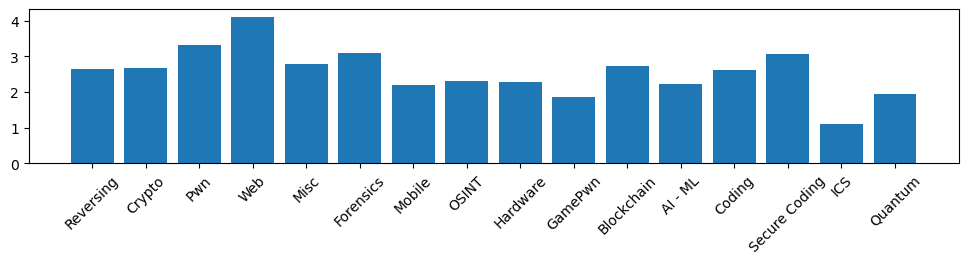

In [ ]:
plt.figure(figsize=(12,2))
plt.xticks(rotation=45)
plt.bar(users_solved_absolute["category"], users_solved_absolute["absolute_avg_solved"])
plt.title("Projsečan broj riješenih zadataka po kategoriji")

In [4]:
users_categories_df["owned_flags"].describe()

count    7320.000000
mean        7.715164
std        11.820521
min         1.000000
25%         2.000000
50%         4.000000
75%         9.000000
max       162.000000
Name: owned_flags, dtype: float64

Text(0, 0.5, 'Postotak riješenosti')

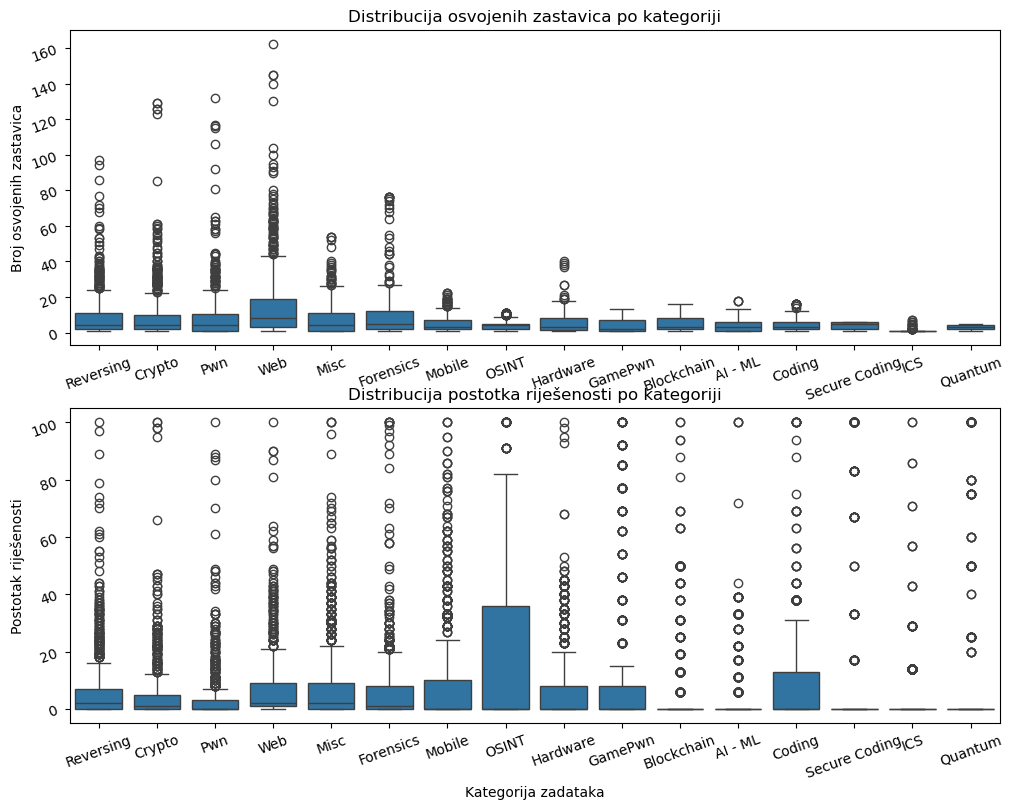

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

sns.boxplot(x=users_categories_df["category"], y=users_categories_df["owned_flags"], ax=axes[0])
axes[0].set_title("Distribucija osvojenih zastavica po kategoriji")
axes[0].tick_params(rotation=20)
axes[0].set_xlabel("Kategorija zadataka")
axes[0].set_ylabel("Broj osvojenih zastavica")


sns.boxplot(x=users_categories_df["category"], y=users_categories_df["completion_percentage"], ax=axes[1])
axes[1].set_title("Distribucija postotka riješenosti po kategoriji")
axes[1].tick_params(rotation=20)
axes[1].set_xlabel("Kategorija zadataka")
axes[1].set_ylabel("Postotak riješenosti")

## Raspodjela po zemljama

In [25]:
team_members_df.size

45840

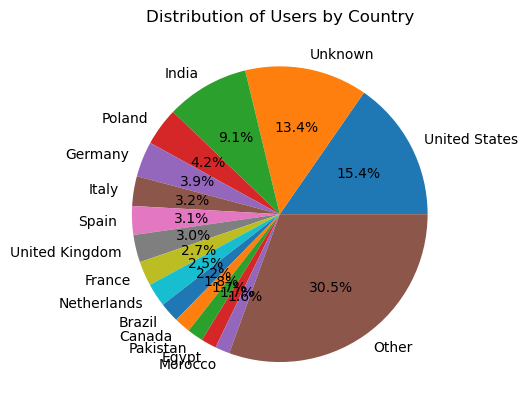

In [26]:
country_grouped = team_members_df.groupby("country_name").size().sort_values(ascending=False)
treshold = 0.015
big_percentage = country_grouped[country_grouped / country_grouped.sum() >= treshold]
other_percentage = country_grouped[country_grouped / country_grouped.sum() < treshold]
big_percentage["Other"] = other_percentage.sum()
plt.pie(big_percentage, labels=big_percentage.index, autopct='%1.1f%%')
plt.title('Distribution of Users by Country')
plt.show()

In [27]:
#other countries
other_percentage.index

Index(['Australia', 'Indonesia', 'Ukraine', 'Vietnam', 'Romania', 'Sri Lanka',
       'Argentina', 'China', 'Switzerland', 'Tunisia',
       ...
       'New Caledonia', 'North Korea', 'Mali', 'Malta', 'Monaco',
       'Christmas Island', 'Botswana', 'British Virgin Islands', 'Uzbekistan',
       'Uruguay'],
      dtype='object', name='country_name', length=130)

## Veličina tima

In [6]:
team_size_data = team_members_df.groupby("team_id").size()
team_size_data.describe()

count    112.000000
mean      25.580357
std       79.589107
min        1.000000
25%        5.750000
50%       10.000000
75%       20.250000
max      758.000000
dtype: float64

In [56]:
team_size_data.sort_values()

team_id
7280      1
7317      1
3766      1
6834      1
5645      1
       ... 
6789     78
6575     84
6462    126
2102    369
6003    758
Length: 112, dtype: int64

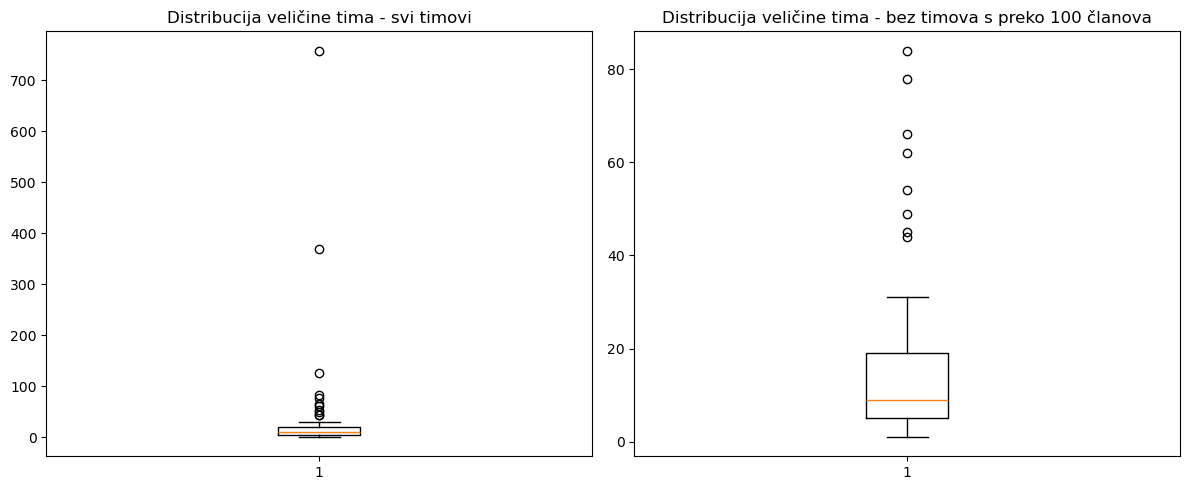

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

upper_bound = 100
filtered = team_size_data[team_size_data <= upper_bound]

axes[0].boxplot(team_size_data)
axes[0].set_title('Distribucija veličine tima - svi timovi')
axes[1].boxplot(filtered)
axes[1].set_title('Distribucija veličine tima - bez timova s preko 100 članova')

plt.tight_layout()
plt.show()


## Odnos ranga tima i ranga članova tima

Doduše, ovo je statistika na 100 najboljih timova i njihovih 900-ish neanonimnih članova pa ima smisla da su svi relativno dobri? Turns out da nisu svi članovi dobri

In [5]:
df1_slim = team_members_df[["id", "name", "rank", "points", "team_id", "role"]]
df2_slim = teams_df[["id", "name", "rank", "points"]]
rank_statistics = df1_slim.merge(df2_slim, left_on="team_id", right_on="id", suffixes=("_user", "_team"))
rank_statistics

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
0,260094,NLTE,247,864,6536,captain,6536,ThugShakers,1,2757
1,1246594,miblak,5,2489,6536,member,6536,ThugShakers,1,2757
2,357237,Sm1l3z,328,710,6536,member,6536,ThugShakers,1,2757
3,143207,22sh,439,550,6536,member,6536,ThugShakers,1,2757
4,1387134,kapiushion03,513,460,6536,member,6536,ThugShakers,1,2757
...,...,...,...,...,...,...,...,...,...,...
2860,523428,GetRektBoy724,unranked,0,5768,member,5768,HCS,100,1062
2861,2782348,erzy,unranked,0,5768,member,5768,HCS,100,1062
2862,1225341,Zumpyx,562,401,6676,captain,6676,CyberFourier,100,1062
2863,1487037,Lusowen,218,942,6676,member,6676,CyberFourier,100,1062


U tablici je 2865 redaka tj. natjecatelja, ali je maksimalni rang 943. To je zato što se rank dijeli među natjecateljima s istim brojem bodova i dodatno postoji 930 natjecatelja s rankom 943. Većina njih ima 0 bodova, ali ne razumijem zašto postoji 176 natjecatelja koji imaju više od 0 bodova, ali su svejedno ranka 943.
    - Jer se bodovi računaju na različit način od ranga

In [6]:
rank_statistics[rank_statistics["rank_user"] == 943]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
82,2761,lynx,943,2,1709,member,1709,WinBARs,6,2570
83,8781,0x5a,943,15,1709,member,1709,WinBARs,6,2570
84,16234,chirality,943,23,1709,member,1709,WinBARs,6,2570
85,40613,MADE,943,0,1709,member,1709,WinBARs,6,2570
86,55159,raiden99,943,0,1709,member,1709,WinBARs,6,2570
...,...,...,...,...,...,...,...,...,...,...
2856,1863416,anarchistxxx,943,0,5768,member,5768,HCS,100,1062
2857,1996861,mintcocs,943,1,5768,member,5768,HCS,100,1062
2858,2163976,honque,943,0,5768,member,5768,HCS,100,1062
2859,2318132,TinyTidy,943,0,5768,member,5768,HCS,100,1062


In [7]:
rank_statistics[(rank_statistics["rank_user"] == 943) & (rank_statistics["points_user"] > 0)]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
82,2761,lynx,943,2,1709,member,1709,WinBARs,6,2570
83,8781,0x5a,943,15,1709,member,1709,WinBARs,6,2570
84,16234,chirality,943,23,1709,member,1709,WinBARs,6,2570
88,122838,Imm0,943,580,1709,member,1709,WinBARs,6,2570
89,124247,kosinw,943,4,1709,member,1709,WinBARs,6,2570
...,...,...,...,...,...,...,...,...,...,...
2789,833625,SecurityEagle,943,1,4161,member,4161,L3G10N,97,1085
2795,1373600,Cosmoxe,943,3,4161,member,4161,L3G10N,97,1085
2835,111344,Rumo,943,27,5490,member,5490,OPTIMA,99,1064
2836,113741,phate32,943,16,5490,member,5490,OPTIMA,99,1064


In [ ]:
# nerangirani su korisnici koji nisu riješili niti jedan zadataka
rank_statistics[rank_statistics["rank_user"]=="unranked"]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
96,83743,clubby789,unranked,56,1709,member,1709,WinBARs,6,2570
97,84315,st4ckh0und,unranked,30,1709,member,1709,WinBARs,6,2570
266,1335237,elite07,unranked,118,6789,member,6789,ISP1337Hackers,9,2477
267,1814651,RiverBoat,unranked,289,6789,member,6789,ISP1337Hackers,9,2477
268,1983898,ShatCod3,unranked,361,6789,member,6789,ISP1337Hackers,9,2477
...,...,...,...,...,...,...,...,...,...,...
2814,2197236,clouddddddd,unranked,0,4161,member,4161,L3G10N,97,1085
2815,2202492,Iqrah0x01,unranked,0,4161,member,4161,L3G10N,97,1085
2816,2206257,lin5472,unranked,0,4161,member,4161,L3G10N,97,1085
2860,523428,GetRektBoy724,unranked,0,5768,member,5768,HCS,100,1062


In [9]:
rank_statistics.loc[rank_statistics["rank_user"] == 'unranked', "rank_user"] = np.nan

In [10]:
rank_statistics["rank_team"] = pd.to_numeric(rank_statistics["rank_team"])
rank_statistics["rank_user"] = pd.to_numeric(rank_statistics["rank_user"])

In [11]:
rank_statistics["rank_user"]

0       247.0
1         5.0
2       328.0
3       439.0
4       513.0
        ...  
2860      NaN
2861      NaN
2862    562.0
2863    218.0
2864    943.0
Name: rank_user, Length: 2865, dtype: float64

In [ ]:
# korisnici u 3 najveća tima
rank_statistics[rank_statistics['id_team'].isin([6462,2102, 6003])]

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
470,1982502,BluePho3nix,915.0,29,6003,captain,6003,HackSmarter,15,2382
471,1586333,simple1337,42.0,2144,6003,member,6003,HackSmarter,15,2382
472,1485206,K4PxD,217.0,982,6003,member,6003,HackSmarter,15,2382
473,1457299,Rivendell,277.0,823,6003,member,6003,HackSmarter,15,2382
474,1718302,Sc4nX,301.0,828,6003,member,6003,HackSmarter,15,2382
...,...,...,...,...,...,...,...,...,...,...
2327,2347643,0x647a,NaN,0,6462,member,6462,NTHW,61,1566
2328,2362140,Ziutek,NaN,0,6462,member,6462,NTHW,61,1566
2329,2375310,seccodesmith,NaN,0,6462,member,6462,NTHW,61,1566
2330,2379673,3man2d3v,NaN,0,6462,member,6462,NTHW,61,1566


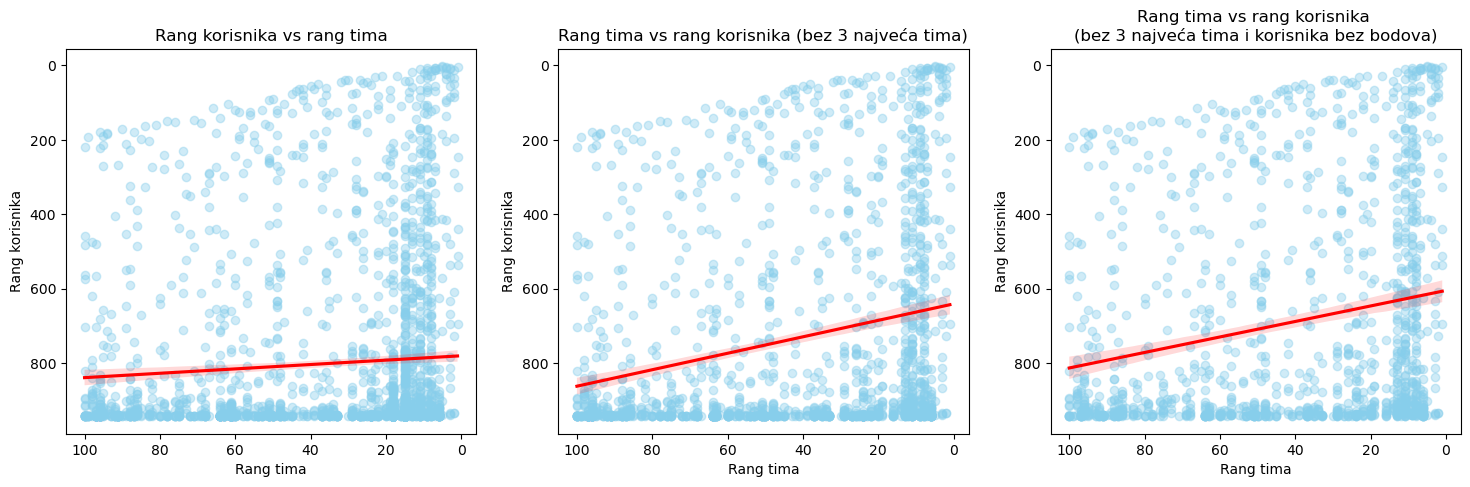

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x=rank_statistics["rank_team"], y=rank_statistics["rank_user"], ax=axes[0], 
            scatter=True, scatter_kws={"color":"skyblue", "alpha":0.4}, 
            line_kws={"color":"red"})
axes[0].set_xlabel("Rang tima")
axes[0].set_ylabel("Rang korisnika")
axes[0].set_title("Rang korisnika vs rang tima")
axes[0].invert_yaxis()
axes[0].invert_xaxis()

# largest teams:
# 6462    126
# 2102    369
# 6003    758
rank_statistics_no_outliers = rank_statistics[~rank_statistics["id_team"].isin([6003, 2102, 6462])]
sns.regplot(x=rank_statistics_no_outliers["rank_team"], y=rank_statistics_no_outliers["rank_user"], ax=axes[1], 
            scatter=True, scatter_kws={"color":"skyblue", "alpha":0.4}, 
            line_kws={"color":"red"})
axes[1].set_xlabel("Rang tima")
axes[1].set_ylabel("Rang korisnika")
axes[1].set_title("Rang tima vs rang korisnika (bez 3 najveća tima)")
axes[1].invert_yaxis()
axes[1].invert_xaxis()


rank_statistics_no_0_points = rank_statistics_no_outliers[rank_statistics_no_outliers["points_user"] > 0]
sns.regplot(x=rank_statistics_no_0_points["rank_team"], y=rank_statistics_no_0_points["rank_user"], ax=axes[2], 
            scatter=True, scatter_kws={"alpha":0.4, "color":"skyblue"}, 
            line_kws={"color":"red"})
axes[2].set_xlabel("Rang tima")
axes[2].set_ylabel("Rang korisnika")
axes[2].set_title("Rang tima vs rang korisnika \n(bez 3 najveća tima i korisnika bez bodova)")
axes[2].invert_yaxis()
axes[2].invert_xaxis()


In [ ]:
#korelacija između ranga tima i ranga korisnika u timu
corr, p = spearmanr(rank_statistics["rank_user"], rank_statistics["rank_team"], nan_policy='omit')
print(f'Spearman Correlation for full rank data: {corr:2f}, p-value: {p:2f}')

corr2, p2 = spearmanr(rank_statistics_no_outliers["rank_user"], rank_statistics_no_outliers["rank_team"], nan_policy='omit')
print(f'Spearman Correlation for rank data without largest teams: {corr2:2f}, p-value: {p2:2f}')

corr3, p3 = spearmanr(rank_statistics_no_0_points["rank_user"], rank_statistics_no_0_points["rank_team"], nan_policy='omit')
print(f'Spearman Correlation for rank data without zero points: {corr3:2f}, p-value: {p3:2f}')

Spearman Correlation for full rank data: 0.096982, p-value: 0.000001
Spearman Correlation for rank data without largest teams: 0.295755, p-value: 0.000000
Spearman Correlation for rank data without zero points: 0.251659, p-value: 0.000000


R-squared: 0.1264


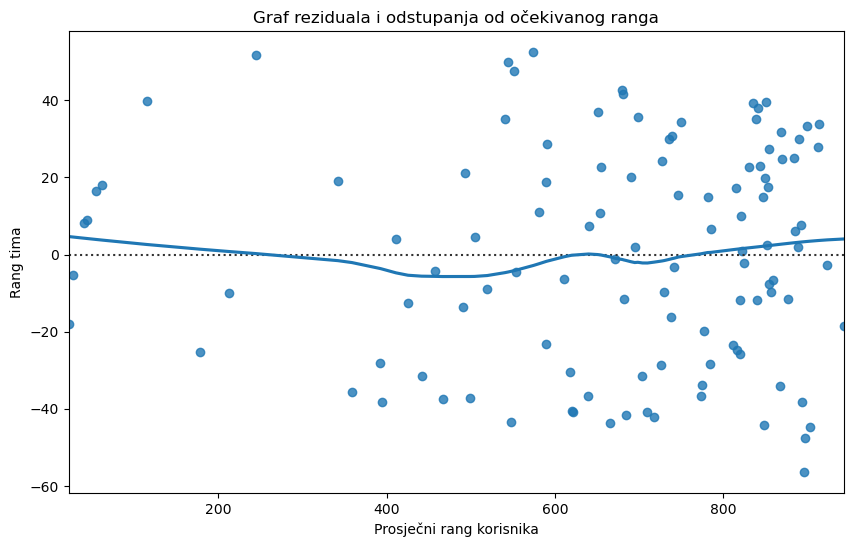

In [ ]:
from sklearn.linear_model import LinearRegression

team_stats = rank_statistics.groupby(['team_id', 'rank_team']).agg({'rank_user': ['mean']}).reset_index()

team_stats.columns = ['team_id', 'rank_team', 'avg_user_rank']
# X: Average User Rank in team, y: Team Rank
X = team_stats[['avg_user_rank']].values 
y = team_stats['rank_team'].values

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)
print(f"R-squared: {r_squared:.4f}")

# Residual = Actual y - Predicted y
predictions = model.predict(X)
team_stats['residuals'] = y - predictions

plt.figure(figsize=(10, 6))
sns.residplot(x=team_stats['avg_user_rank'], y=team_stats['rank_team'], lowess=True)
plt.title('Graf reziduala i odstupanja od očekivanog ranga')
plt.xlabel('Prosječni rang korisnika')
plt.ylabel('Rang tima')
plt.show()

Točke ispod linije su timovi koji su bolji nego bi se očekivalo na temelju njihovog sastava tj na temelju ranga njegovih članova. Timovi iznad linije su timovi koji imaju niži rang nego bi se očekivalo na temeljui njegovih članova. zelena linija pokazuje da timovi s članovima na pola liste performaju bolje nego bi se od njih očekivalo, a uzdizanje iznad nule s lijeve i desne strane znači da jako dobri i jako loši timovi ne dorastaju onome što linearni model od njih očekuje. 

In [17]:
team_stats[team_stats['residuals'] < -40].sort_values(by='residuals')

,team_id,rank_team,avg_user_rank,residuals
7,1709,6,896.095238,-56.424852
43,6003,15,897.066087,-47.469727
10,2102,18,903.031847,-44.745481
24,4449,16,848.000000,-44.201764
49,6248,8,665.661290,-43.773590
40,5904,3,547.647059,-43.318663
103,7369,12,717.571429,-42.173013
64,6575,11,684.072289,-41.624595
78,6859,13,709.892308,-40.818064
71,6789,9,621.586667,-40.736346


Id timova koji imaju jako niske reziduale:
1709
6003
2102
4449
6248
5904
7369
6575
6859	
6789	
1371

Ovi timovi iznad performaju puno bolje nego bi se od njih očekivalo, kasnije kad budem gledala strukturu, pogledati njih detaljno

In [20]:
rank_statistics_no_0_points

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
0,260094,NLTE,247.0,864,6536,captain,6536,ThugShakers,1,2757
1,1246594,miblak,5.0,2489,6536,member,6536,ThugShakers,1,2757
2,357237,Sm1l3z,328.0,710,6536,member,6536,ThugShakers,1,2757
3,143207,22sh,439.0,550,6536,member,6536,ThugShakers,1,2757
4,1387134,kapiushion03,513.0,460,6536,member,6536,ThugShakers,1,2757
...,...,...,...,...,...,...,...,...,...,...
2852,2002868,kokon,942.0,1,5768,member,5768,HCS,100,1062
2853,2457867,takanami,942.0,1,5768,member,5768,HCS,100,1062
2857,1996861,mintcocs,943.0,1,5768,member,5768,HCS,100,1062
2862,1225341,Zumpyx,562.0,401,6676,captain,6676,CyberFourier,100,1062


In [21]:
rank_statistics_no_outliers

,id_user,name_user,rank_user,points_user,team_id,role,id_team,name_team,rank_team,points_team
0,260094,NLTE,247.0,864,6536,captain,6536,ThugShakers,1,2757
1,1246594,miblak,5.0,2489,6536,member,6536,ThugShakers,1,2757
2,357237,Sm1l3z,328.0,710,6536,member,6536,ThugShakers,1,2757
3,143207,22sh,439.0,550,6536,member,6536,ThugShakers,1,2757
4,1387134,kapiushion03,513.0,460,6536,member,6536,ThugShakers,1,2757
...,...,...,...,...,...,...,...,...,...,...
2860,523428,GetRektBoy724,NaN,0,5768,member,5768,HCS,100,1062
2861,2782348,erzy,NaN,0,5768,member,5768,HCS,100,1062
2862,1225341,Zumpyx,562.0,401,6676,captain,6676,CyberFourier,100,1062
2863,1487037,Lusowen,218.0,942,6676,member,6676,CyberFourier,100,1062


## Odnos ranga i veličine tima

In [8]:
team_rank = teams_df[["id", "rank"]].rename(columns={"rank": "rank_team", "id": "id_team"})
rank_size_statistics = team_rank.merge(team_size_data.rename("team_size"), left_on="id_team", right_index=True)
rank_size_statistics.sort_values("team_size", ascending=False)

,id_team,rank_team,team_size
17,6003,15,758
20,2102,18,369
65,6462,61,126
13,6575,11,84
10,6789,9,78
...,...,...,...
42,5645,40,1
44,3766,42,1
33,6834,31,1
34,394,32,1


In [9]:
rank_size_statistics_no_outliers = rank_size_statistics[~rank_size_statistics["id_team"].isin([6003, 2102, 6462])]

Text(0.5, 1.0, 'Veličina tima vs rang tima (timovi manji od 40 članova)')

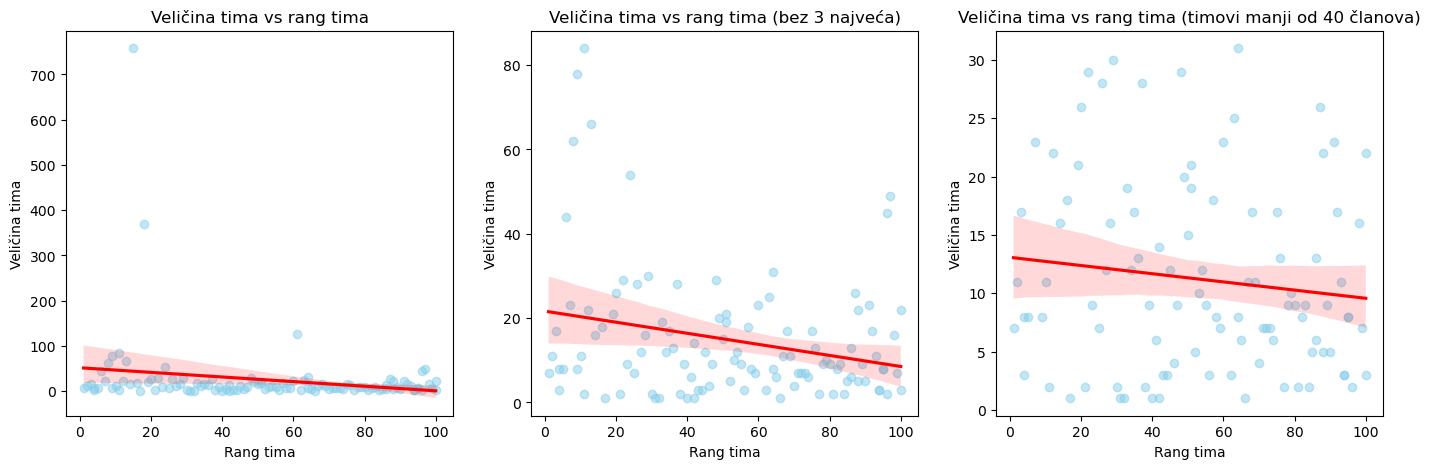

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.regplot(x=rank_size_statistics["rank_team"], y=rank_size_statistics['team_size'], ax=axes[0],
            scatter=True, scatter_kws={"color":"skyblue", "alpha":0.5},
            line_kws={"color":"red"})
axes[0].set_xlabel("Rang tima")
axes[0].set_ylabel("Veličina tima")
axes[0].set_title("Veličina tima vs rang tima")

sns.regplot(x=rank_size_statistics_no_outliers['rank_team'], y=rank_size_statistics_no_outliers['team_size'], ax=axes[1],
            scatter=True, scatter_kws={"color":"skyblue", "alpha":0.5},
            line_kws={"color":"red"})
axes[1].set_xlabel("Rang tima")
axes[1].set_ylabel("Veličina tima")
axes[1].set_title("Veličina tima vs rang tima (bez 3 najveća)")

smaller_teams = rank_size_statistics[rank_size_statistics['team_size'] <= 40]
sns.regplot(x=smaller_teams['rank_team'], y=smaller_teams['team_size'], ax=axes[2],
            scatter=True, scatter_kws={"color":"skyblue", "alpha":0.5},
            line_kws={"color":"red"})
axes[2].set_xlabel("Rang tima")
axes[2].set_ylabel("Veličina tima")
axes[2].set_title("Veličina tima vs rang tima (timovi manji od 40 članova)")

In [11]:
# Ima li statističke korelacije između veličine tima i ranga tima?
rho, p_s = spearmanr(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
r, p_p = pearsonr(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
k, p_k = kendalltau(rank_size_statistics['team_size'], rank_size_statistics['rank_team'])
print('Coefficients za korelaciju između veličine tima i ranga tima:')
print('Spearman:', rho, p_s)
print('Pearson:', r, p_p)
print('Kendall Tau:', k, p_k)


Coefficients za korelaciju između veličine tima i ranga tima:
Spearman: -0.18959730214727222 0.04526337139728963
Pearson: -0.19219673172538176 0.04233934558156263
Kendall Tau: -0.1310137436081168 0.043977213497293055


vrijednost korelacije je slaba ali postoji, ali statistički značajna jer je p vrijednosti ispod 0.05, za sva tri testa

In [12]:
rho, p_s = spearmanr(smaller_teams['team_size'], smaller_teams['rank_team'])
r, p_p = pearsonr(smaller_teams['team_size'], smaller_teams['rank_team'])
k, p_k = kendalltau(smaller_teams['team_size'], smaller_teams['rank_team'])
print('Koeficijenti za korelaciju između veličine tima i ranga tima bez velikih timova:')
print('Spearman:', rho, p_s)
print('Pearson:', r, p_p)
print('Kendall Tau:', k, p_k)

Koeficijenti za korelaciju između veličine tima i ranga tima bez velikih timova:
Spearman: -0.106766531964376 0.28792914258518776
Pearson: -0.12509011979225743 0.21261966541557537
Kendall Tau: -0.07345920248419802 0.28594085853518336


Ovo bez velikih timova ne drži vodu, p vrijednost prevelika da bi bilo statistički značajno

In [13]:
rho, p_s = spearmanr(rank_size_statistics_no_outliers['team_size'], rank_size_statistics_no_outliers['rank_team'])
r, p_p = pearsonr(rank_size_statistics_no_outliers['team_size'], rank_size_statistics_no_outliers['rank_team'])
k, p_k = kendalltau(rank_size_statistics_no_outliers['team_size'], rank_size_statistics_no_outliers['rank_team'])
print('Koeficijenti za korelaciju između veličine tima i ranga tima bez 3 najveća tima:')
print('Spearman:', rho, p_s)
print('Pearson:', r, p_p)
print('Kendall Tau:', k, p_k)

Koeficijenti za korelaciju između veličine tima i ranga tima bez 3 najveća tima:
Spearman: -0.16516096845596973 0.0861146124701529
Pearson: -0.2540216233636036 0.007690650252056729
Kendall Tau: -0.1156472535884909 0.07981638980580129


Kada uklonimo stršeće vrijednosti, sigurnost Pearsonovog statističkog testa u korelaciju se povećava, ali spearman i kendall više nisu statistički značajni 

In [14]:
avg = rank_size_statistics.groupby('team_size')['rank_team'].agg(['mean','count','std']).reset_index()


Text(0.5, 1.0, 'Prosječni rang tima vs veličina tima - sa standardnom devijacijom')

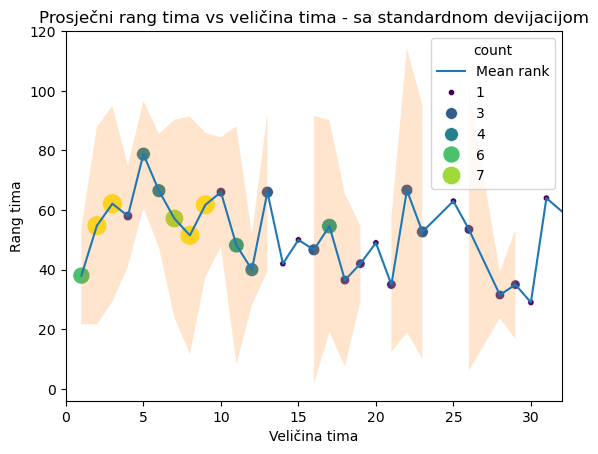

In [15]:
plt.plot(avg['team_size'], avg['mean'], color='C0', label='Mean rank')
sns.scatterplot(
    data=avg,
    x='team_size',
    y='mean',
    size='count',        # map point size to count
    sizes=(20, 200),     # min and max dot size
    hue='count',         # optional: color by count too
    palette='viridis'
)
plt.xlim(0, 32)
plt.fill_between(avg['team_size'], avg['mean'] - avg['std'], avg['mean'] + avg['std'], alpha=0.2, label='±1 SE')
plt.xlabel('Veličina tima')
plt.ylabel('Rang tima')
plt.title('Prosječni rang tima vs veličina tima - sa standardnom devijacijom')

In [16]:
ins = [0, 5, 15, 40, 1000]
labels = ['Small', 'Medium', 'Large', 'Massive']
rank_size_statistics['size_category'] = pd.cut(rank_size_statistics['team_size'], bins=ins, labels=labels)

groups = [rank_size_statistics[rank_size_statistics['size_category'] == label]['rank_team'] for label in labels]
stat, p = kruskal(*groups)

print(f"Značajna razlika u rangu između različitih veličina tima? - statistika = {stat}, p = {p:.5f}")
print("Ne")

Značajna razlika u rangu između različitih veličina tima? - statistika = 6.040542859351873, p = 0.10965
Ne


## Odnos korisničkih bodova i timskih bodova

Broj bodova u timu je nekakva linearna kombinacija bodova članova, pa se uvodi nekakva multikolinearnost? Ima li smisla ovo provjeravati?

Osim toga, broj bodova je prilično sličan rangu

In [17]:
team_points = teams_df[["id", "points"]].rename(columns={"points": "points_team", "id": "id_team"})
member_points = team_members_df[["id", "team_id", "points"]].rename(columns={"points": "points_user", "team_id": "id_team", "id": "id_user"})
team_vs_member_points = member_points.merge(team_points, on="id_team")
team_vs_member_points

,id_user,id_team,points_user,points_team
0,260094,6536,864,2757
1,1246594,6536,2489,2757
2,357237,6536,710,2757
3,143207,6536,550,2757
4,1387134,6536,460,2757
...,...,...,...,...
2860,523428,5768,0,1062
2861,2782348,5768,0,1062
2862,1225341,6676,401,1062
2863,1487037,6676,942,1062


<Axes: title={'center': 'User Points vs Team Points'}, xlabel='points_team', ylabel='points_user'>

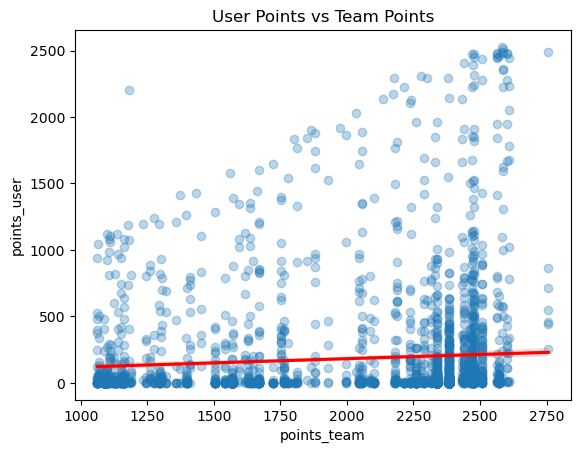

In [87]:
plt.scatter(team_vs_member_points['points_team'], team_vs_member_points['points_user'], alpha=0.3)
plt.xlabel("Team Points")
plt.ylabel("User Points")
plt.title("User Points vs Team Points")
sns.regplot(x='points_team', y='points_user', data=team_vs_member_points, scatter=False, color='red')

In [18]:
corr_points = team_vs_member_points[['points_team', 'points_user']].corr()
rho, p_s = spearmanr(team_vs_member_points['points_team'], team_vs_member_points['points_user'])
r, p_p = pearsonr(team_vs_member_points['points_team'], team_vs_member_points['points_user'])
k, p_k = kendalltau(team_vs_member_points['points_team'], team_vs_member_points['points_user'])
print('Koeficijenti za korelaciju između bodova tima i bodova korisnika:')
print('Spearman:', rho, p_s)
print('Pearson:', r, p_p)
print('Kendall Tau:', k, p_k)

Koeficijenti za korelaciju između bodova tima i bodova korisnika:
Spearman: 0.06505575606186102 0.0004933776347445446
Pearson: 0.07196418854307682 0.000115610763123685
Kendall Tau: 0.043843876229834065 0.0013270428818447002


## Što natjecatelji najviše rješavaju

In [60]:
users_categories_df.describe()

,owned_flags,total_flags,completion_percentage,avg_user_solved
count,7320.000000,17952.000000,17952.000000,17952.000000
mean,7.715164,50.092580,7.407030,13.705221
std,11.820521,50.787052,16.593746,13.090181
min,1.000000,4.000000,0.000000,2.080000
25%,2.000000,12.500000,0.000000,3.720000
50%,4.000000,19.500000,0.000000,11.380000
75%,9.000000,81.250000,6.000000,16.595000
max,162.000000,162.000000,100.000000,51.150000


Volumno, najviše igraju web pa ostale standardne kategorije pa onda ostale kategorije na HTB. MEeđutim, kad se gleda postotak riješenosti dostupnih zadataka, najveća je prosječna riješenost OSINT zadataka

<BarContainer object of 16 artists>

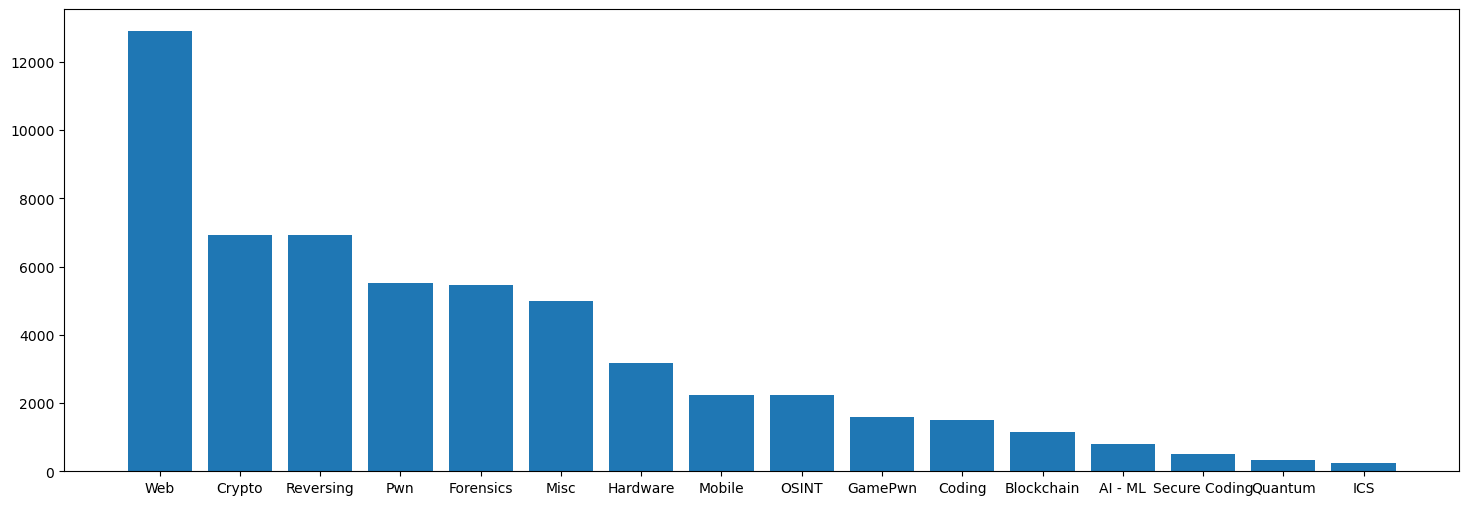

In [25]:
owned_per_category = users_categories_df.groupby("category")["owned_flags"].sum().sort_values(ascending=False)
plt.figure(figsize=(18,6))
plt.bar(owned_per_category.index, owned_per_category.values)

<BarContainer object of 16 artists>

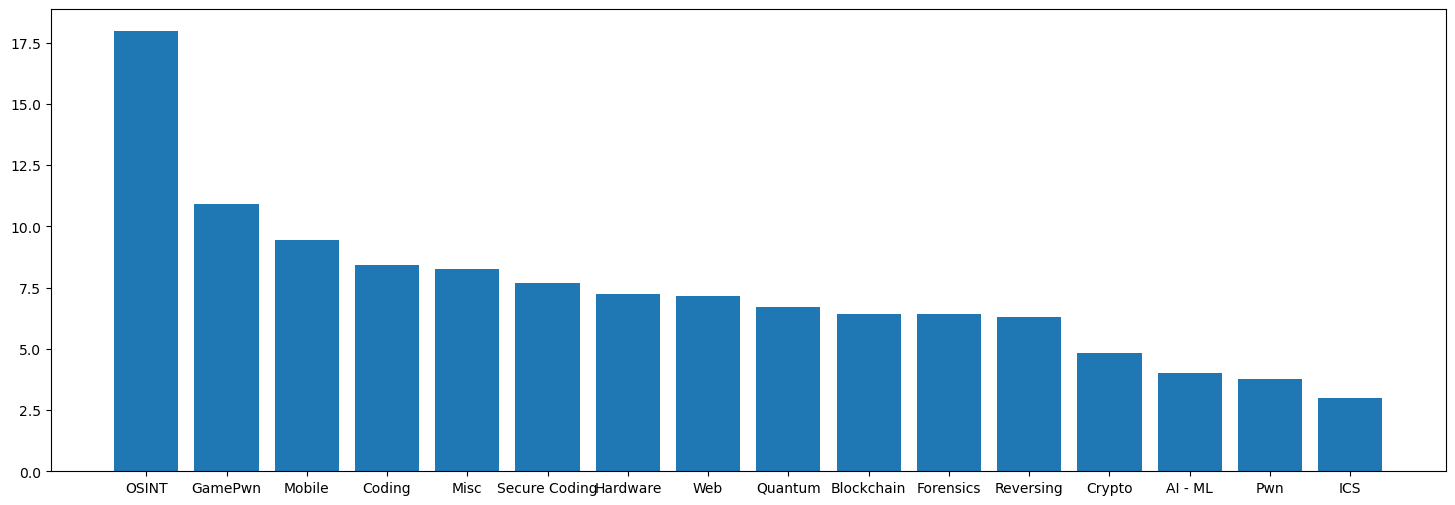

In [26]:
owned_per_category_percentage = users_categories_df.groupby("category")["completion_percentage"].mean().sort_values(ascending=False)
plt.figure(figsize=(18,6))
plt.bar(owned_per_category_percentage.index, owned_per_category_percentage.values)  

<Axes: xlabel='category', ylabel='owned_flags'>

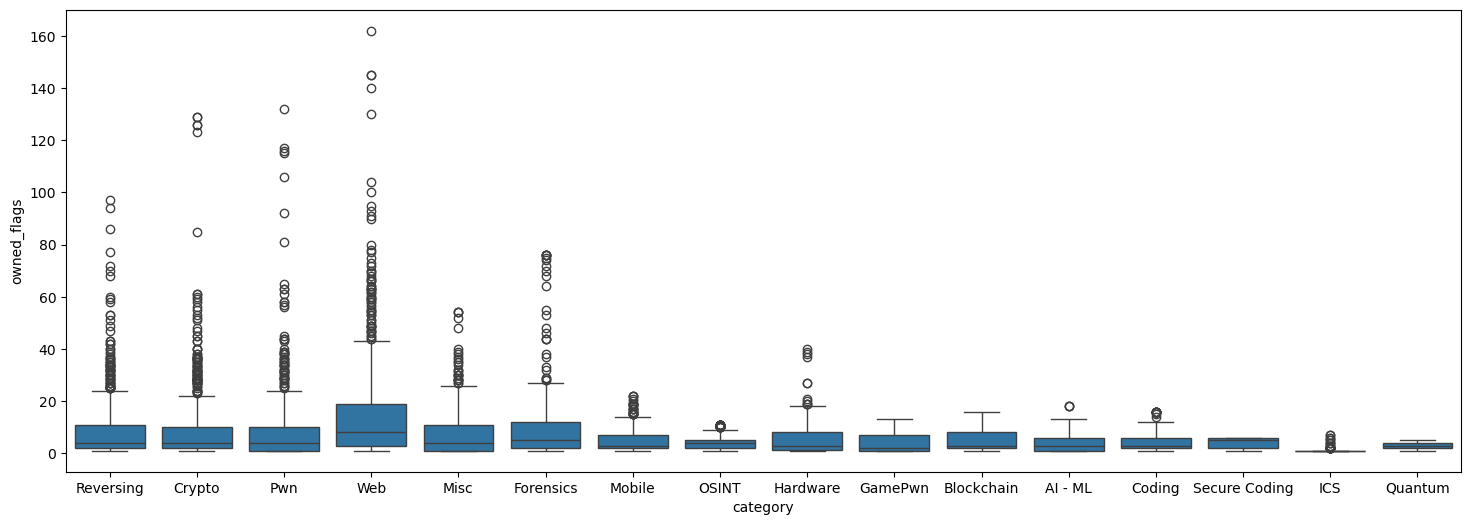

In [27]:
user_categories_box = (users_categories_df.groupby(['id', 'category']).size().reset_index(name='solved_count'))
plt.figure(figsize=(18, 6))
sns.boxplot(data=users_categories_df, x="category", y="owned_flags")

## Profili igrača

##### Helper funkcije (ugl crtanje repetitivnih grafova)

In [152]:
def get_bucket(rank):
    if rank <= 10: return 'Top 10'
    if rank <= 20: return 'Top 20'
    if rank <= 50: return 'Top 50'
    return 'ostali'

In [57]:
def get_pca_graph(df, clusters, name_map, name_order, color_map, legend_elements):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)

    pca = PCA(n_components=2, random_state=0)
    coords = pca.fit_transform(X_scaled)

    plot_df = pd.DataFrame(coords, index=df.index, columns=['pc1', 'pc2'])
    plot_df['cluster_name'] = pd.Series(clusters, index=df.index).map(name_map)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x='pc1',
        y='pc2',
        hue='cluster_name',
        hue_order=name_order,
        palette=color_map,
        s=20,
        alpha=0.7
    )
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title("Analiza glavnih komponenti za profile igrača")
    plt.legend(title='Profil', handles = legend_elements)


In [17]:
def get_clustermap(data, row_colors, cluster_info):
    plotting_data = data.drop(columns=['cluster'])
    g = sns.clustermap(
        plotting_data,
        row_colors=row_colors, 
        row_cluster=False,
        col_cluster=False,
        cmap='viridis',
        figsize=(10, 8),
        standard_scale=1,
        cbar_pos=(0.02, 0.1, 0.03, 0.15)
    )
    g.ax_cbar.set_title('Prosječna \nriješenost')
    g.ax_heatmap.set_yticks([])
    g.ax_heatmap.set_xlabel('Kategorija')
    g.ax_heatmap.set_ylabel('Korisnici')
    g.ax_heatmap.set_title('Toplinska karta s grupiranjem po profilu')
    legend_elements = [
        Patch(facecolor=info['color'], label=info['name']) 
        for info in cluster_info.values()
    ]
    g.ax_heatmap.legend(loc='upper left', bbox_to_anchor=(-0.5, 1.2), title='Profili', handles=legend_elements)
    
    total_rows = len(data)
    current_row = 0
    cluster_counts = data['cluster'].value_counts().sort_index()
    ordered_clusters = data['cluster'].unique()

    for cluster_id in ordered_clusters:
        count = cluster_counts[cluster_id]
        percentage = (count / total_rows) * 100
        
        # Calculate the vertical center of this cluster's block
        y_center = current_row + (count / 2)
        # x position: data.shape[1] is the right edge
        g.ax_row_colors.text(
            x=-2, 
            y=y_center, 
            s=f"N={count}\n({percentage:.1f}%)",
            verticalalignment='center',
            horizontalalignment='left',
            fontsize=9
        )
        current_row += count

In [68]:
def get_avg_profile_heatmap(data):
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap='viridis',
        cbar_kws={'label': 'Prosječni udio riješenosti'} 
    )

    plt.title('Prosječna riješenost kategorije po profilu igrača', fontsize=15)
    plt.xlabel('Kategorija zadataka', fontsize=12)
    plt.ylabel('Profil', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [158]:
def generate_bar_plot(df1, df2, axes, name_order, color_map, plot_name):
    df1.set_index('team_id')[name_order].plot(
    kind='bar', 
    stacked=True,  
    color=[color_map[name] for name in name_order], 
    ax=axes[0], 
    legend=False
    )
    axes[0].set_title(f"Struktura {plot_name} timova")
    axes[0].set_ylabel("Broj igrača u timu")
    axes[0].set_xlabel("Identifikator tima (sortiran po rangu)")

    df2.plot(
        kind='bar', 
        stacked=True,  
        color=[color_map[name] for name in name_order], 
        ax=axes[1]
    )

    axes[1].set_title(f"Proporcionalna struktura {plot_name} timova")
    axes[1].set_ylabel("Postotak tima")
    axes[1].set_xlabel("Rang tima")
    axes[1].legend(title="Profili", bbox_to_anchor=(1.05, 1), loc='upper left')

    # fig.savefig(filename)


In [160]:
def generate_all_bar_plots(team_structure_grouped, name_order, color_map):
    # Top 10 timova
    fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
    top_10_teams_nonpublic = team_structure_grouped.sort_values('team_rank').head(10).reset_index()
    top_10_teams_nonpublic_normalized = top_10_teams_nonpublic[name_order].div(top_10_teams_nonpublic['team_size'], axis=0)
    generate_bar_plot(top_10_teams_nonpublic, top_10_teams_nonpublic_normalized, axes1, name_order, color_map, "Top 10") 

    # Top 20 timova
    fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
    top_20_teams_nonpublic = team_structure_grouped.sort_values('team_rank').head(20).reset_index()
    top_20_teams_nonpublic_normalized= top_20_teams_nonpublic[name_order].div(top_20_teams_nonpublic['team_size'], axis=0)
    generate_bar_plot(top_20_teams_nonpublic, top_20_teams_nonpublic_normalized, axes2, name_order, color_map, "Top 20")

    # Other teams - sub 50
    fig3, axes3 = plt.subplots(1, 2, figsize=(15, 5))
    other_teams_nonpublic = team_structure_grouped[team_structure_grouped['rank_bucket']=='ostali'].reset_index()
    other_teams_nonpublic_normalized = other_teams_nonpublic[name_order].div(other_teams_nonpublic['team_size'], axis=0)
    generate_bar_plot(other_teams_nonpublic, other_teams_nonpublic_normalized, axes3, name_order, color_map, "ostalih")

##### Nastavak analize

In [19]:
# matrica user-category sa postocima riješenosti zadataka u kategoriji
user_category_completion = users_categories_df.pivot_table(
    index='id',
    columns='category',
    values='completion_percentage',  # = owned_flags / total_flags
    fill_value=0
)

user_category_completion_main_categories ispod nije normalizirano po retku da bih imala stvarnu predodžbu koliki postotak dostupnih zadataka su riješili.

Ako je netko sve radio malo i to malo se zbroji u 1, onda će izgledati kao da je jako dobar u tim kategorijama, ali nije jer je rješavao samo malo.

In [20]:
main_categories = ['Web', 'Pwn', 'Crypto', 'Forensics', 'Reversing', 'Misc', 'OSINT']
user_category_completion_main_categories = users_categories_df[users_categories_df['category'].isin(main_categories)].pivot_table(
    index='id',
    columns='category',
    values='completion_percentage', 
    fill_value=0
)

In [21]:
user_category_completion_main_categories.head()

category,Crypto,Forensics,Misc,OSINT,Pwn,Reversing,Web
id,,,,,,,
1001444,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1001763,4.0,3.0,2.0,55.0,2.0,3.0,4.0
1006675,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1007696,1.0,0.0,0.0,0.0,2.0,1.0,6.0
1009617,0.0,1.0,2.0,0.0,0.0,0.0,4.0


### Heatmap riješenosti zadataka po kategoriji za svakog usera

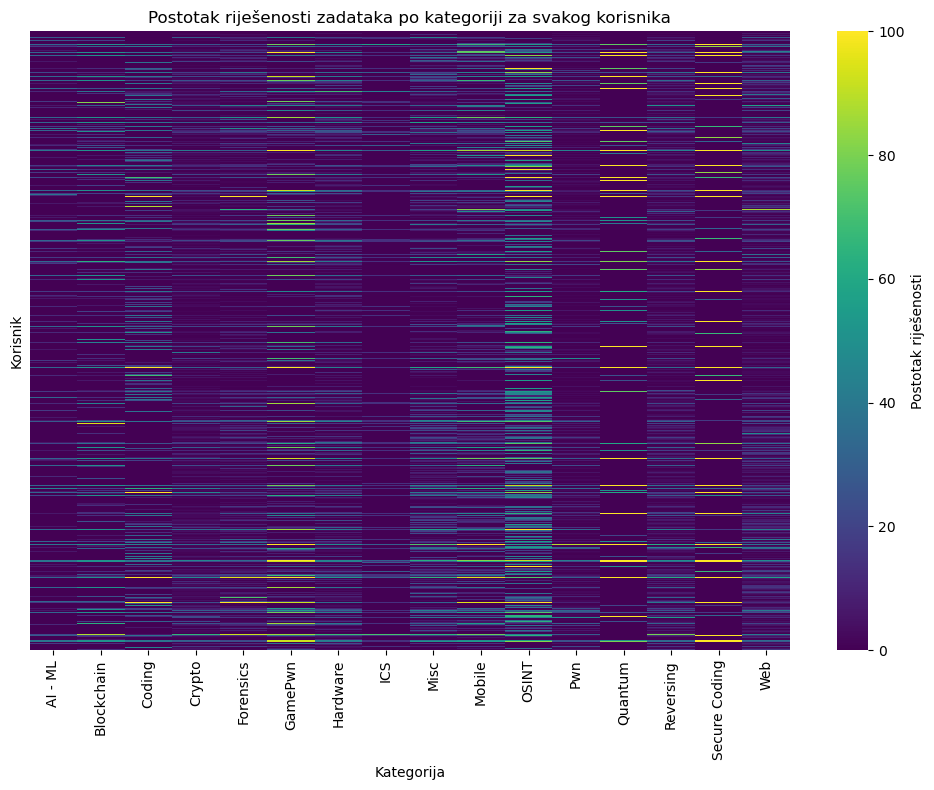

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    user_category_completion,
    cmap='viridis',
    cbar_kws={'label': 'Postotak riješenosti'},
)
plt.xlabel('Kategorija')
plt.ylabel('Korisnik')
plt.yticks([])
plt.title('Postotak riješenosti zadataka po kategoriji za svakog korisnika')
plt.tight_layout()
plt.show()

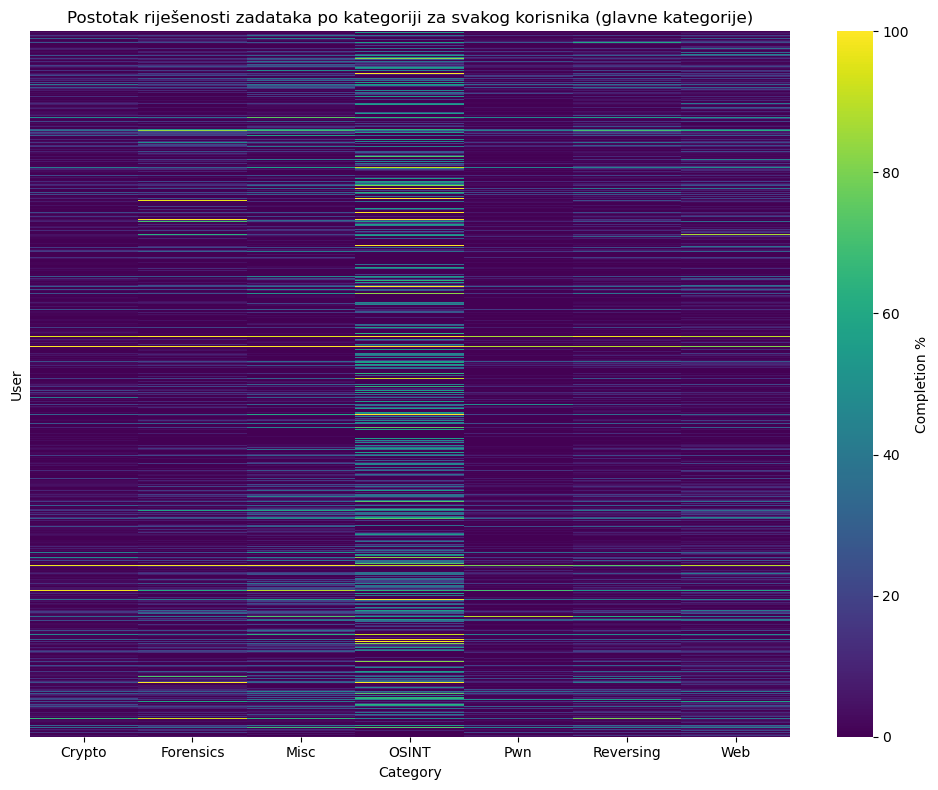

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    user_category_completion_main_categories,
    cmap='viridis',
    cbar_kws={'label': 'Completion %'},
)
plt.xlabel('Category')
plt.ylabel('User')
plt.yticks([])
plt.title('Postotak riješenosti zadataka po kategoriji za svakog korisnika (glavne kategorije)')
plt.tight_layout()
plt.show()

### Clustering po specijalnosti/profilima - originalne grupe

/tmp/ipykernel_30761/3056403945.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profiles_main = profiles_main.fillna(0)


Text(0, 0.5, 'Inercija')

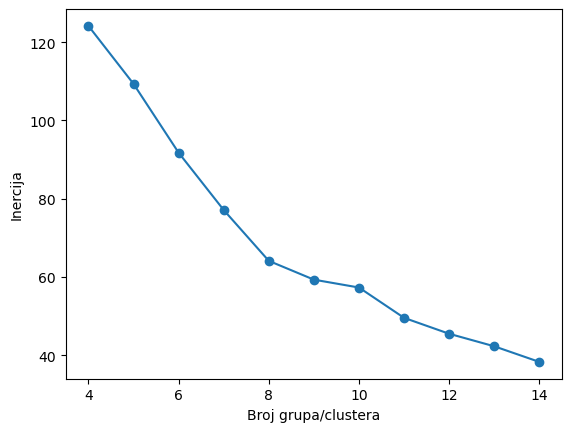

In [24]:
row_sums_main = user_category_completion_main_categories.sum(axis=1)

profiles_main = user_category_completion_main_categories.div(row_sums_main.replace(0, pd.NA), axis=0)
profiles_main = profiles_main.fillna(0)

inertias = []
for k in range(4, 15):
    km = KMeans(n_clusters=k, random_state=0)
    clusters = km.fit_predict(profiles_main)
    inertias.append(km.inertia_)
    
plt.plot(range(4, 15), inertias, marker='o')
plt.xlabel('Broj grupa/clustera')
plt.ylabel('Inercija')

Text(0, 0.5, 'Silhouette Score')

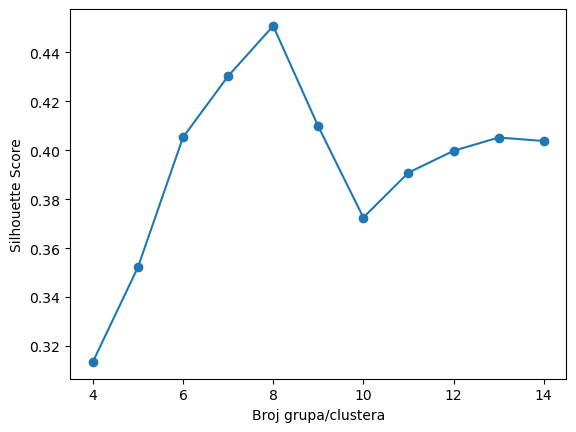

In [25]:
sil_scores = []
for k in range(4, 15):
    km = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = km.fit_predict(profiles_main)
    sil_scores.append(silhouette_score(profiles_main, labels))
plt.plot(range(4, 15), sil_scores, marker='o')
plt.xlabel('Broj grupa/clustera')
plt.ylabel('Silhouette Score')

#### Clustering na cijelom datasetu na temelju glavnih kategorija - 8 clustera

Iz grafova analize siluete (al ovo nije analiza siluete nego samo siluette score), i metode koljena odlučujemo da je optimalni broj grupa 8.

In [29]:
k = 8  # number of archetypes you want
km = KMeans(n_clusters=k, random_state=0, n_init='auto')

In [63]:
cluster_info_8 = {
    0: {"name": "Stručnjak za OSINT", "color": "blue"},
    1: {"name": "Uravnoteženi \ngeneralist", "color": "orange"},
    2: {"name": "Stručnjak za Web", "color": "green"},
    3: {"name": "Generalist fokusiran \nna OSINT", "color": "red"},
    4: {"name": "Neaktivni korisnik", "color": "purple"},
    5: {"name": "Stručnjak za \nkriptografiju", "color": "brown"},
    6: {"name": "Stručnjak za reverzno \n inženjerstvo", "color": "pink"},
    7: {"name": "Specijalist za \nMisc", "color": "gray"}
}

# Helper objects for plotting
name_map_8 = {k: v["name"] for k, v in cluster_info_8.items()}
color_map_8 = {v["name"]: v["color"] for k, v in cluster_info_8.items()}
ordered_names_8 = [cluster_info_8[i]["name"] for i in range(8)]

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info_8.values()
]

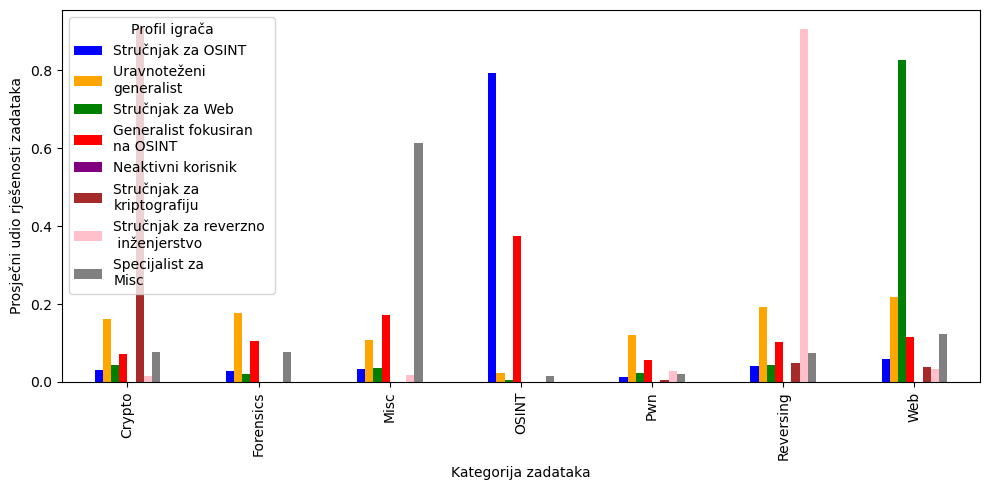

In [77]:
clusters = km.fit_predict(profiles_main)
profile_clustered_main_8 = profiles_main.copy()
profile_clustered_main_8['cluster'] = clusters

cluster_mean_main_8 = profile_clustered_main_8.groupby('cluster').mean()
plot_data = cluster_mean_main_8.T

plot_data.columns = [name_map_8[i] for i in plot_data.columns]
ax = plot_data.plot(kind='bar', figsize=(10, 5), color=[color_map_8[name] for name in plot_data.columns])
plt.xlabel('Kategorija zadataka')
plt.ylabel('Prosječni udio rješenosti zadataka')
plt.legend(title='Profil igrača', labels=ordered_names_8)
plt.tight_layout()
plt.show()


Ne mogu zaključiti na kakve komponente je rastavio

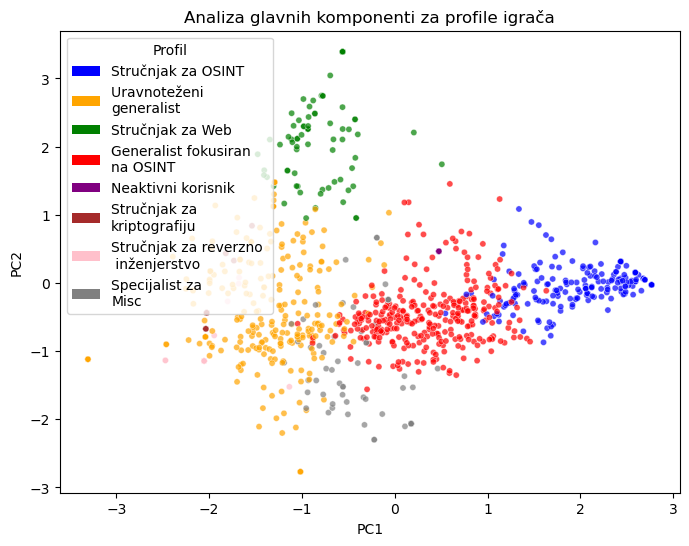

In [78]:
get_pca_graph(profiles_main, clusters, name_map_8, ordered_names_8, color_map_8, legend_elements)

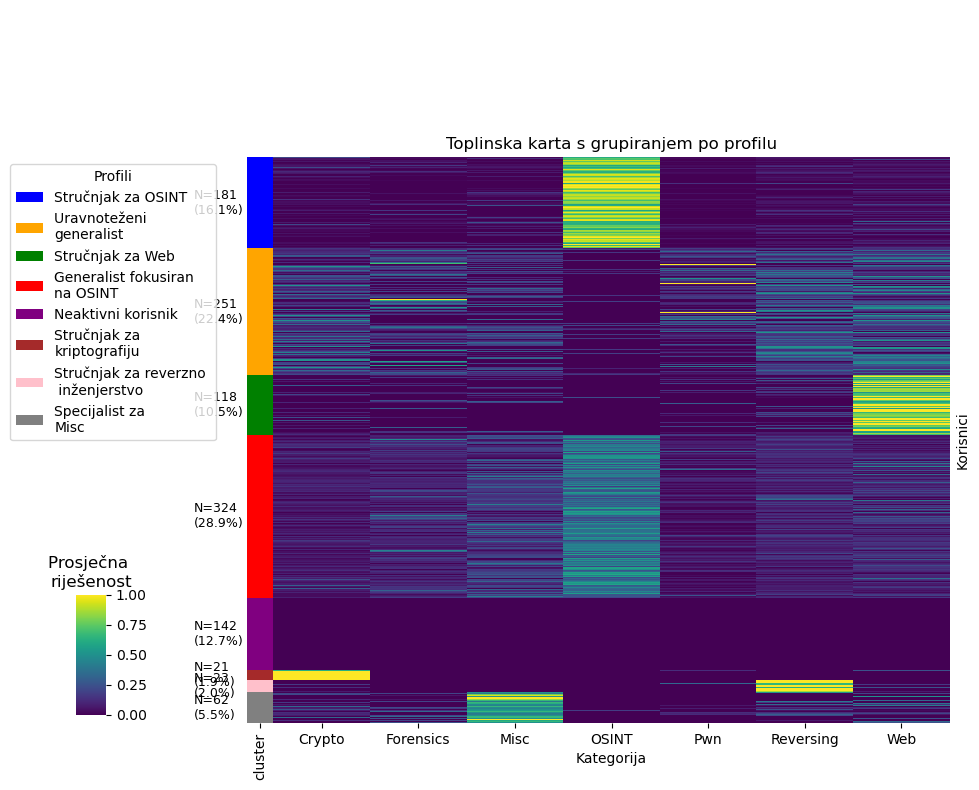

In [79]:
profile_sorted = profile_clustered_main_8.sort_values('cluster')
row_colors = profile_sorted['cluster'].map(lambda x: cluster_info_8[x]['color'])
get_clustermap(profile_sorted, row_colors, cluster_info_8)


In [ ]:
# Average archetype profiles
category_order = ["OSINT", "Web", "Misc", "Reversing", "Crypto", "Forensics", "Pwn"]
avg_heatmap_data_8 = cluster_mean_main_8.copy()
avg_heatmap_data_8.index = avg_heatmap_data_8.index.map(lambda x: cluster_info_8[x]['name'])
avg_heatmap_data_8 = avg_heatmap_data_8.reindex(columns=category_order)

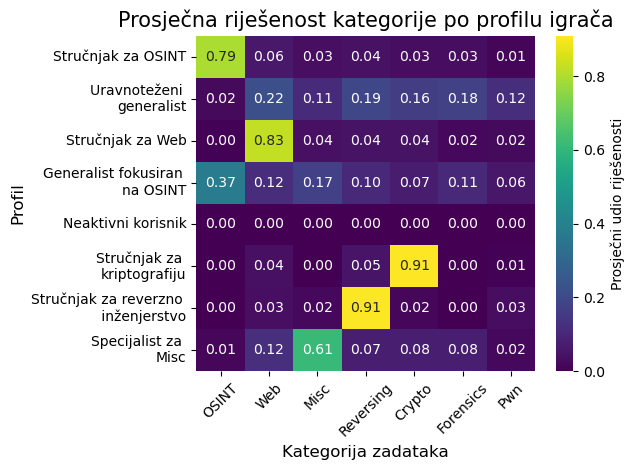

In [81]:
get_avg_profile_heatmap(avg_heatmap_data_8)

#### Struktura tima

In [ ]:
profile_clustered_main_8 = profile_clustered_main_8.reset_index()
profile_clustered_main_8 = profile_clustered_main_8.rename(columns={'index': 'id'})
profile_clustered_main_8['id'] = pd.to_numeric(profile_clustered_main_8['id'])
profile_clustered_main_8.head()

category,id,Crypto,Forensics,Misc,OSINT,Pwn,Reversing,Web,cluster
0,1001444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4
1,1001763,0.054795,0.041096,0.027397,0.753425,0.027397,0.041096,0.054795,0
2,1006675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4
3,1007696,0.100000,0.000000,0.000000,0.000000,0.200000,0.100000,0.600000,2
4,1009617,0.000000,0.142857,0.285714,0.000000,0.000000,0.000000,0.571429,2


In [53]:
ranks = teams_df[['id', 'rank']].rename(columns={'rank': 'team_rank', 'id': 'team_id'})

team_structure_df_8 = team_members_df[['id', 'team_id', 'rank']].merge(
    profile_clustered_main_8[['id', 'cluster']], 
    on='id',
    how='left'
).rename(columns={'rank': 'user_rank'}).merge(
    ranks,
    on='team_id',
    how='left'
)

team_structure_df_8.describe()

,id,team_id,cluster,team_rank
count,2.865000e+03,2865.000000,1122.000000,2865.000000
mean,1.217990e+06,5347.560209,2.409982,33.914834
std,7.961807e+05,1827.860351,1.837611,28.186946
min,3.810000e+02,91.000000,0.000000,1.000000
25%,4.488120e+05,4252.000000,1.000000,15.000000
50%,1.252835e+06,6003.000000,3.000000,18.000000
75%,1.950753e+06,6555.000000,3.000000,56.000000
max,2.913874e+06,7993.000000,7.000000,100.000000


In [ ]:
# Preimenovanje clustera u imena profila i dodavanje nonpublic
team_structure_df_8['cluster_name'] = team_structure_df_8['cluster'].map(name_map_8).fillna("Nonpublic")
team_structure_grouped_8 = team_structure_df_8.groupby(['team_id', 'team_rank'])['cluster_name'].value_counts().unstack(fill_value=0)
team_structure_grouped_8['team_size'] = team_structure_grouped_8.sum(axis=1)

team_structure_grouped_8['rank_bucket'] = team_structure_grouped_8.index.get_level_values('team_rank').map(get_bucket)


##### Ispravljanje greške o nedostatku timova pojedinih rankova

Neću ispravljati kod koji je ispod budući da je služio za jednokratno ispravljanje greške koja se potkrala u učitavanju podataka

In [ ]:
team_structure_grouped.describe()

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,team_size
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.00000
mean,1.774510,2.460784,1.156863,3.176471,1.392157,0.205882,0.225490,0.607843,11.00000
std,3.590159,4.361559,2.970965,5.506813,5.468464,0.762204,0.643426,1.463462,20.92703
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.00000
50%,1.000000,1.000000,0.000000,1.500000,0.000000,0.000000,0.000000,0.000000,6.00000
75%,2.000000,3.000000,1.000000,3.750000,1.000000,0.000000,0.000000,1.000000,11.75000
max,22.000000,30.000000,26.000000,43.000000,50.000000,6.000000,4.000000,12.000000,152.00000


In [92]:
team_structure_df['team_rank'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [93]:
team_structure_grouped.index.unique(level="team_rank").sort_values()

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
        30,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        45,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,
        60,  61,  63,  64,  65,  66,  67,  68,  70,  71,  72,  73,  74,  75,
        76,  78,  79,  80,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98, 100],
      dtype='int64', name='team_rank')

Zašto 91 red, zar nije 112 timova?? Vidjeti koji nedostaje
    rankovi: 1, 2, 3, 4, 5, 6, 7, 8, 9, 17, 31, 46, 62, 69, 77, 81, 99 = 17 rankova

    edit: ispravljeno

In [111]:
missing_ranks = [1, 2, 3, 4, 5, 6, 7, 8, 9, 17, 31, 46, 62, 69, 77, 81, 99]
team_structure_df[team_structure_df['team_rank'].isin(missing_ranks)]['team_id'].unique()

array([6536, 7086, 5904, 6618, 6900, 1750, 1709, 7142, 6248, 1371, 6789,
       7280, 6834, 7591, 4142, 5326, 6792, 6282, 5490])

U prvom redu je top 9 timova - članovi dodani u top_9_teams.jsonl 
U drugom redu su ostali timovi koji nedostaju - nedostaju jer su im svi članovi non public - oni su u other_missing_teams.jsonl

Imamo objašnjenje za 19 od nedostajućih 21 timova (91 tim od 112 je u team_structure_df)

Prikupila sam preko apija nedostajućih 11 timova na rangovima 1-9 i dodani su u user_profiles. Ponovno pokrenula ćelije za stvaranje users tablica i svega ostalog

##### Nastavak rada

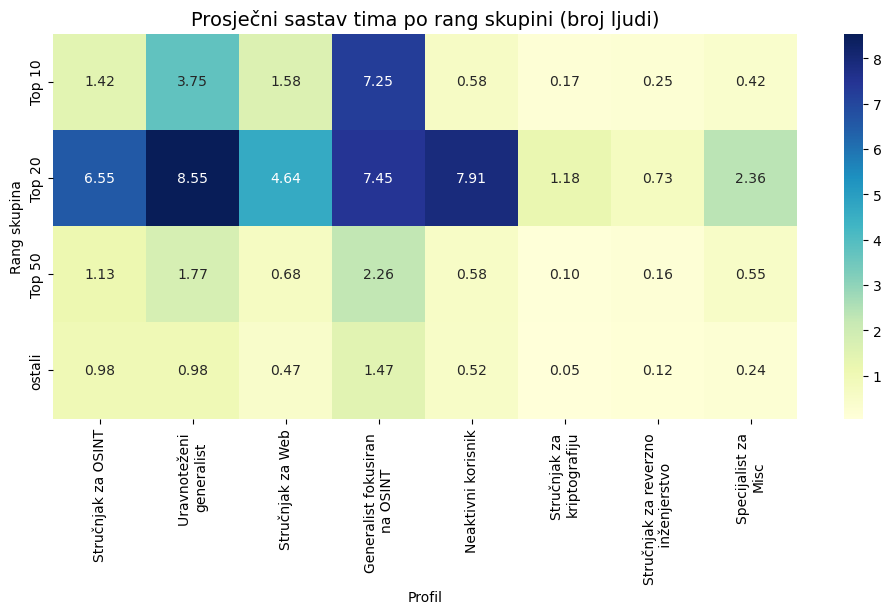

In [85]:
bucket_averages = team_structure_grouped_8.groupby('rank_bucket')[ordered_names_8].mean()
bucket_order = ['Top 10', 'Top 20', 'Top 50', 'ostali']
bucket_averages = bucket_averages.reindex(bucket_order)

plt.figure(figsize=(12, 5))
sns.heatmap(bucket_averages, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Prosječni sastav tima po rang skupini (broj ljudi)", fontsize=14)
plt.xlabel("Profil")
plt.ylabel("Rang skupina")
plt.show()

In [90]:
# adding nonpublic players
cluster_info_nonpublic_8 = {
    0: {"name": "Stručnjak za OSINT", "color": "blue"},
    1: {"name": "Uravnoteženi \ngeneralist", "color": "orange"},
    2: {"name": "Stručnjak za Web", "color": "green"},
    3: {"name": "Generalist fokusiran \nna OSINT", "color": "red"},
    4: {"name": "Neaktivni korisnik", "color": "purple"},
    5: {"name": "Stručnjak za \nkriptografiju", "color": "brown"},
    6: {"name": "Stručnjak za reverzno \n inženjerstvo", "color": "pink"},
    7: {"name": "Specijalist za \nMisc", "color": "gray"},
    8: {"name": "Nonpublic", "color": "black"}
}
name_map_nonpublic_8 = {k: v["name"] for k, v in cluster_info_nonpublic_8.items()}
color_map_nonpublic_8 = {v["name"]: v["color"] for k, v in cluster_info_nonpublic_8.items()}
ordered_names_nonpublic_8 = [cluster_info_nonpublic_8[i]["name"] for i in range(9)]

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info_nonpublic_8.values()
]

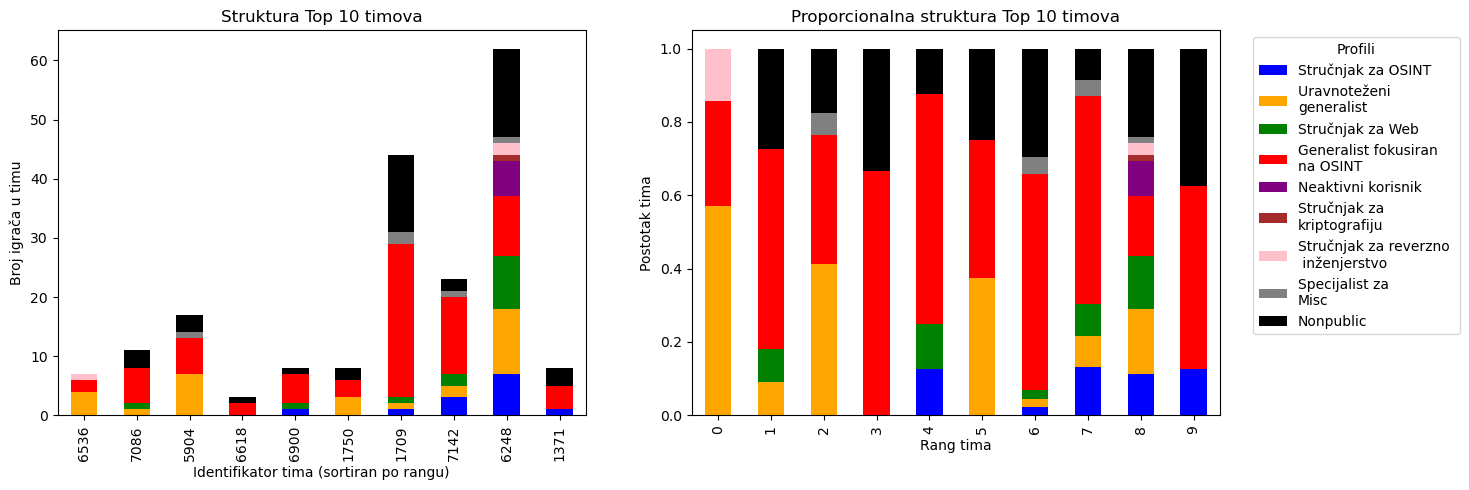

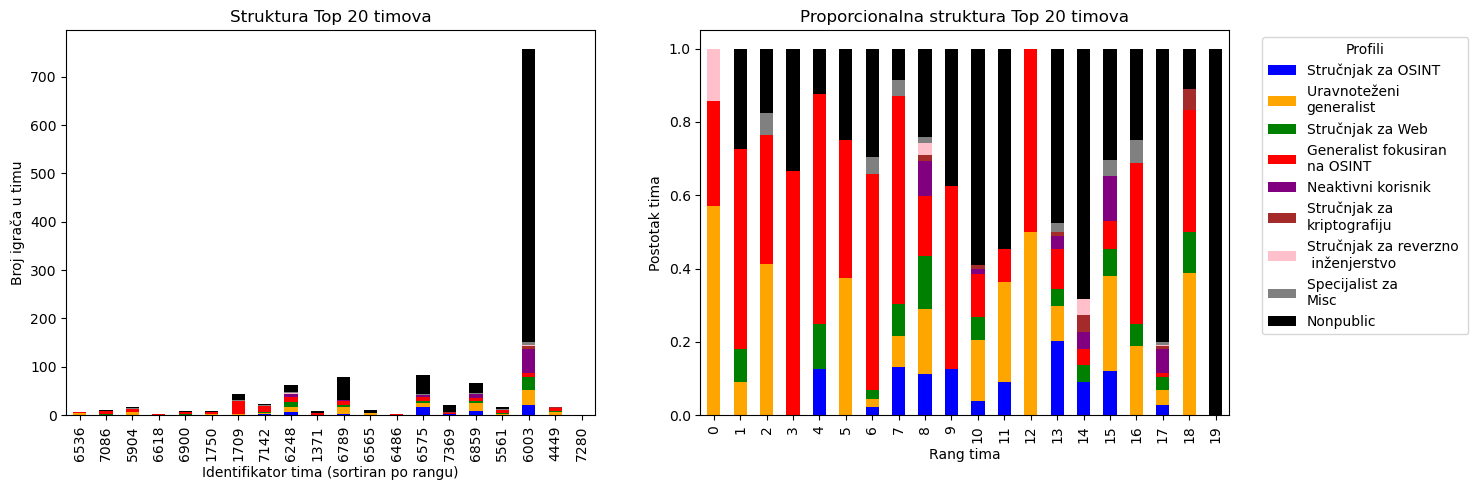

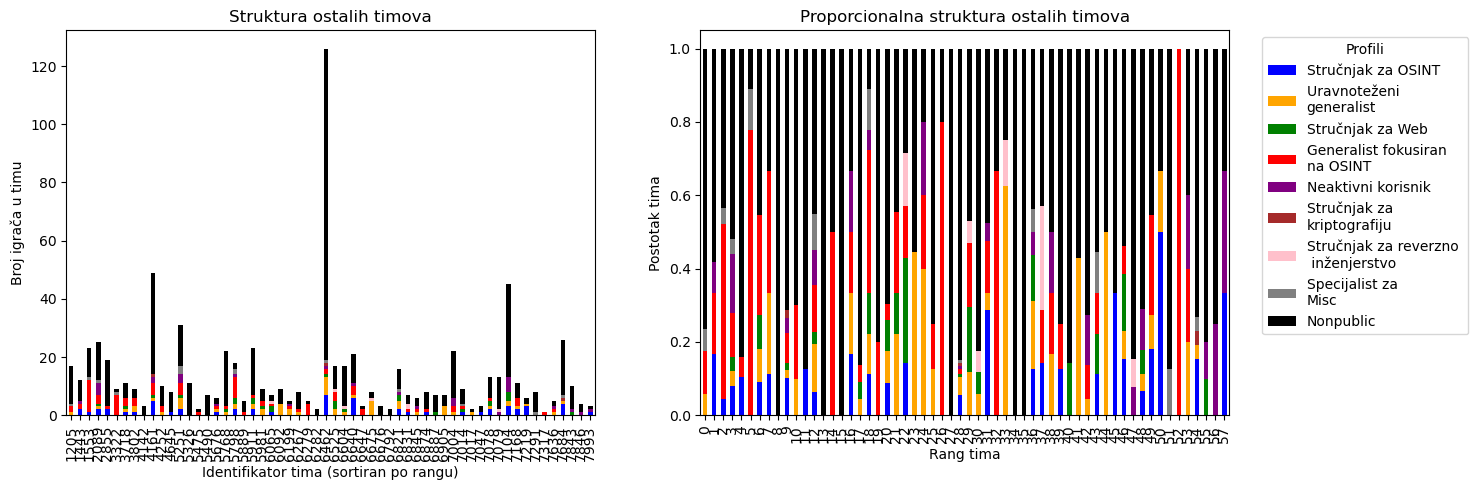

In [163]:
generate_all_bar_plots(team_structure_grouped_8, ordered_names_nonpublic_8, color_map_nonpublic_8)

### Redefiniranje dataseta - grupiranje čudnih kategorija u najsličniju glavnu

In [8]:
group_map = {
    'Web': 'Web',
    'Pwn': 'Pwn',
    'GamePwn': 'Pwn',
    'Reversing': 'Reversing',
    'Crypto': 'Crypto',
    'Quantum': 'Crypto',
    'Forensics': 'Forensics',
    'Coding': 'Misc',
    'OSINT': 'Misc',
    'Misc': 'Misc',
    'Secure Coding': 'Misc',
    'Hardware': 'Hardware',
    'ICS': 'ICS',
    'Mobile': 'Mobile',
    'AI - ML': 'AI - ML',
    'Blockchain': 'Blockchain'}

#### Clustering po specijalnosti/profilima - nove grupe, treniranje na glavnim grupama

In [9]:
# treniranje samo na glavim kategorijama
users_categories_grouped_df = users_categories_df.copy()
users_categories_grouped_df['category'] = users_categories_grouped_df['category'].map(group_map)

grouped_aggregated = users_categories_grouped_df[users_categories_grouped_df['category'].isin(
    ['Web', 'Pwn', 'Crypto', 'Forensics', 'Reversing', 'Misc'])].groupby(
        ['id', 'category']).agg(
        owned_flags_sum=('owned_flags', 'sum'), 
        total_flags_sum=('total_flags', 'sum')).reset_index()

grouped_aggregated['completion_percent'] = (
    grouped_aggregated['owned_flags_sum'] / grouped_aggregated['total_flags_sum'] * 100
)

user_category_percentage = grouped_aggregated.pivot_table(
    index='id',
    columns='category',
    values='completion_percent',
    fill_value=0
)

row_sums = user_category_percentage.sum(axis=1)
profiles = user_category_percentage.div(row_sums.replace(0, pd.NA), axis=0)
profiles = profiles.fillna(0)

/tmp/ipykernel_142560/357423510.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profiles = profiles.fillna(0)


In [99]:
profiles

category,Crypto,Forensics,Misc,Pwn,Reversing,Web
id,,,,,,
1001444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1001763,0.178021,0.077884,0.442239,0.081644,0.091534,0.128678
1006675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1007696,0.085908,0.000000,0.000000,0.157596,0.117791,0.638705
1009617,0.000000,0.212501,0.185633,0.000000,0.000000,0.601866
...,...,...,...,...,...,...
990600,0.182056,0.000000,0.490715,0.126184,0.125750,0.075295
994939,0.045779,0.000000,0.349921,0.000000,0.188308,0.415993
998019,0.272629,0.000000,0.279941,0.083982,0.062770,0.300677


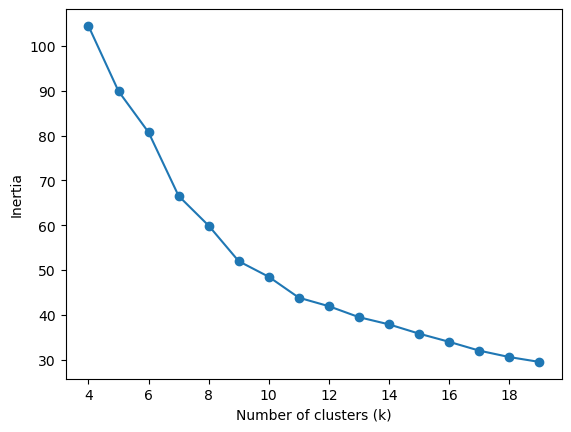

In [32]:
inertias = []
sil_scores = []
for k in range(4, 20):
    km = KMeans(n_clusters=k, random_state=0)
    clusters = km.fit_predict(profiles)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(profiles, clusters))
    
plt.plot(range(4, 20), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

Text(0, 0.5, 'Silhouette Score')

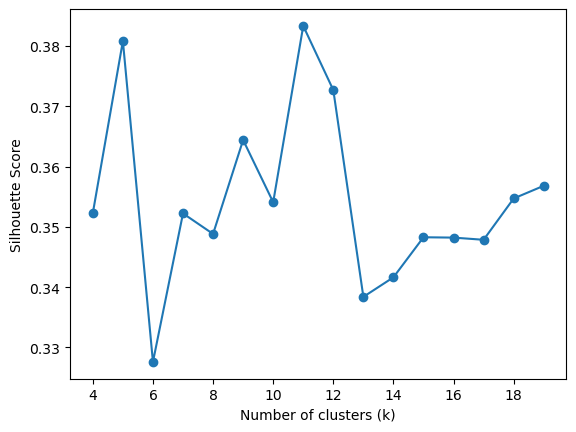

In [33]:
plt.plot(range(4, 20), sil_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')

#### Clustering na grupiranom datasetu na temelju glavnih kategorija - 5 clustera

In [ ]:
cluster_info_5 = {
    0: {"name": "Specijalist za Misc", "color": "blue"},
    1: {"name": "Fokusiran na \nRev i Crypto", "color": "orange"},
    2: {"name": "Stručnjak za Web", "color": "green"},
    3: {"name": "Neaktivan koji \nradi Pwn?", "color": "red"},
    4: {"name": "Balansirani \ngeneralist", "color": "purple"}
}

# Helper objects for plotting
name_map_5 = {k: v["name"] for k, v in cluster_info_5.items()}
color_map_5 = {v["name"]: v["color"] for k, v in cluster_info_5.items()}
ordered_names_5 = [cluster_info_5[i]["name"] for i in range(5)]

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info_5.values()
]

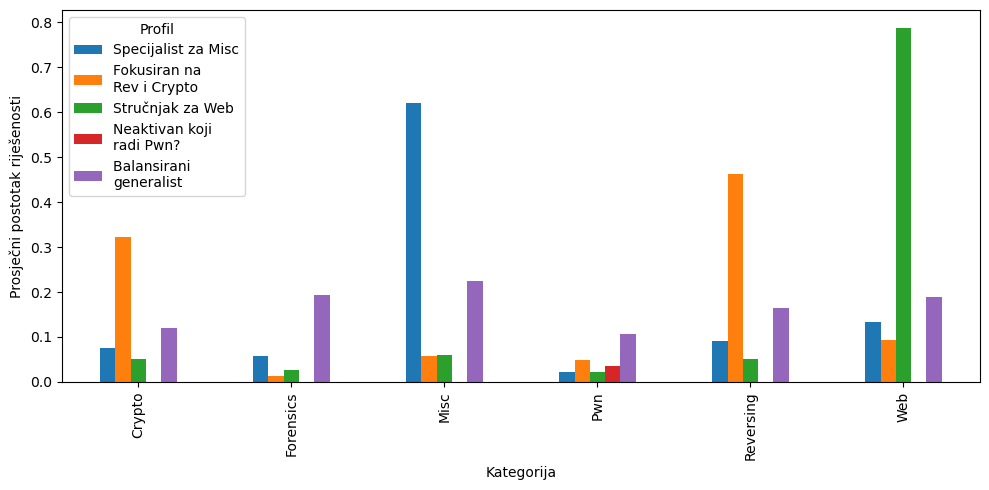

In [139]:
# Iako je supposedly optimalan, meni ovaj clustering nema smisla jer su ljudi koji su riješili puno pwn clusterani s ljuidima koji ne znaju apsolutno ništa. 

km = KMeans(n_clusters=5, random_state=0, n_init='auto')
clusters = km.fit_predict(profiles)
profile_clustered_main_5 = profiles.copy()
profile_clustered_main_5['cluster'] = clusters

cluster_mean_5 = profile_clustered_main_5.groupby('cluster').mean()
cluster_mean_5.T.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Kategorija')
plt.ylabel('Prosječni postotak riješenosti')
plt.legend(title='Profil', labels=ordered_names_5)
plt.tight_layout()
plt.show()

##### Grafovi

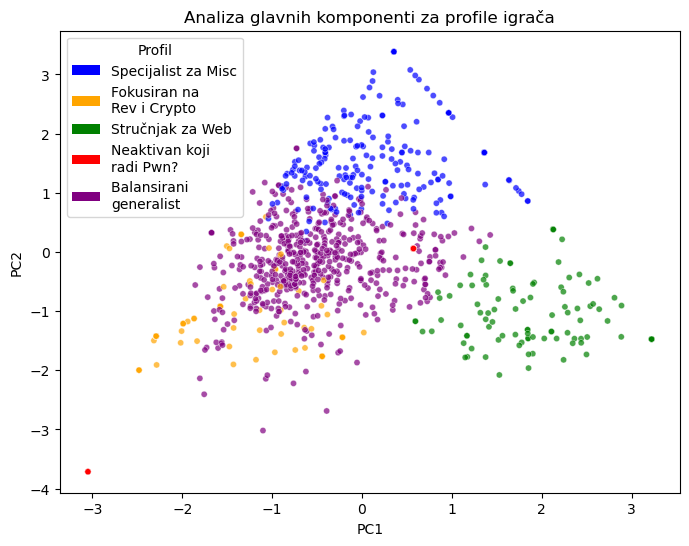

In [140]:
get_pca_graph(profiles, clusters, name_map_5, ordered_names_5, color_map_5, legend_elements)

In [141]:
dbi_5 = davies_bouldin_score(profiles, clusters)
print(f"Davies-Bouldin Index (k=5): {dbi_5:.4f}")

Davies-Bouldin Index (k=5): 1.2027


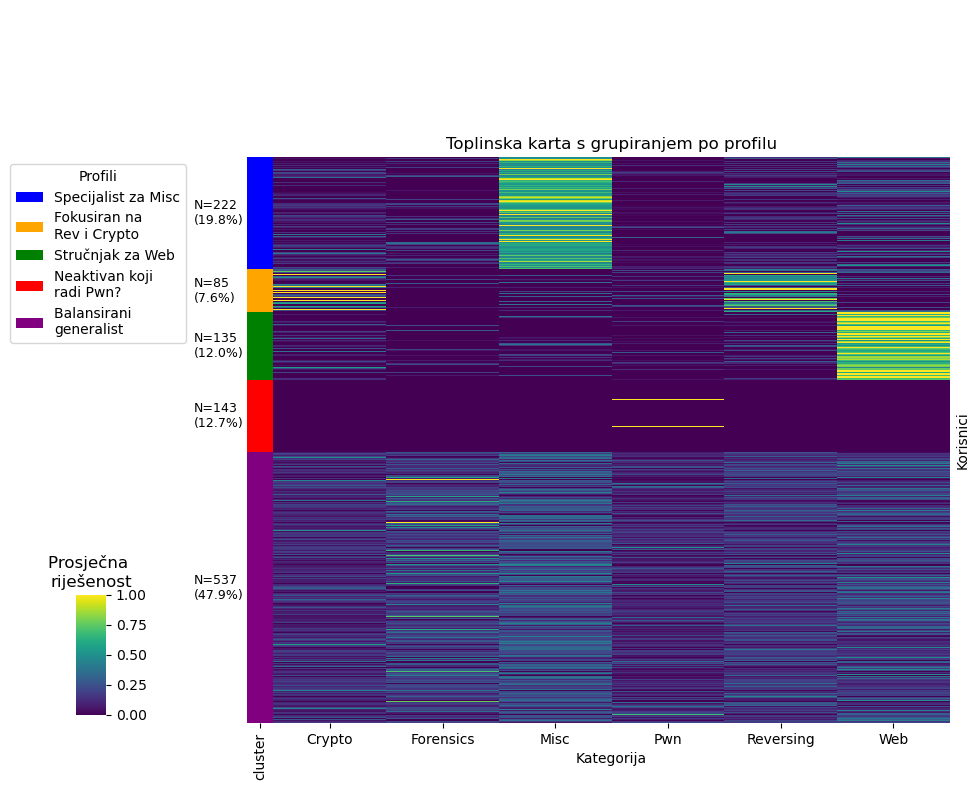

In [142]:
profile_sorted = profile_clustered_main_5.sort_values('cluster')
row_colors = profile_sorted['cluster'].map(lambda x: cluster_info_5[x]['color'])

get_clustermap(profile_sorted, row_colors, cluster_info_5)

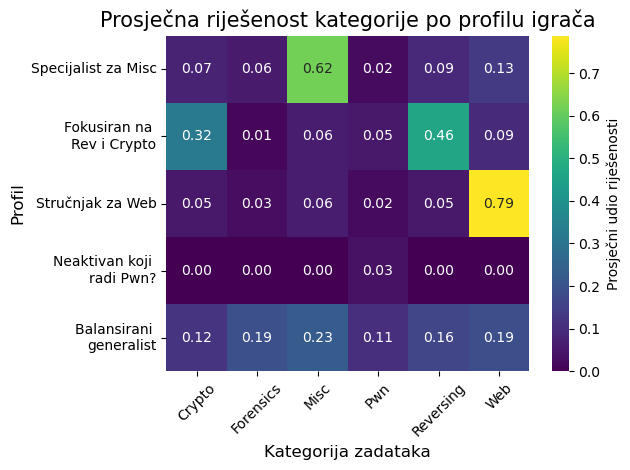

In [143]:
# Average archetype profiles
category_order = ["Crypto", "Forensics", "Misc","Pwn", "Reversing", "Web"]

avg_heatmap_data_5 = cluster_mean_5.copy()
avg_heatmap_data_5.index = avg_heatmap_data_5.index.map(lambda x: cluster_info_5[x]['name'])
avg_heatmap_data_5 = avg_heatmap_data_5.reindex(columns=category_order)
get_avg_profile_heatmap(avg_heatmap_data_5)

##### Team Structure



In [144]:
profile_clustered_main_5 = profile_clustered_main_5.reset_index()
profile_clustered_main_5 = profile_clustered_main_5.rename(columns={'index': 'id'})
profile_clustered_main_5['id'] = pd.to_numeric(profile_clustered_main_5['id'])
profile_clustered_main_5.head()

category,id,Crypto,Forensics,Misc,Pwn,Reversing,Web,cluster
0,1001444,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3
1,1001763,0.178021,0.077884,0.442239,0.081644,0.091534,0.128678,0
2,1006675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3
3,1007696,0.085908,0.000000,0.000000,0.157596,0.117791,0.638705,2
4,1009617,0.000000,0.212501,0.185633,0.000000,0.000000,0.601866,2


In [145]:
ranks = teams_df[['id', 'rank']].rename(columns={'rank': 'team_rank', 'id': 'team_id'})

team_structure_df_5 = team_members_df[['id', 'team_id', 'rank']].merge(
    profile_clustered_main_5[['id', 'cluster']], 
    on='id',
    how='left'
).rename(columns={'rank': 'user_rank'}).merge(
    ranks,
    on='team_id',
    how='left'
)

team_structure_df_5.describe()

,id,team_id,cluster,team_rank
count,2.865000e+03,2865.000000,1122.000000,2865.000000
mean,1.217990e+06,5347.560209,2.613191,33.914834
std,7.961807e+05,1827.860351,1.592278,28.186946
min,3.810000e+02,91.000000,0.000000,1.000000
25%,4.488120e+05,4252.000000,1.000000,15.000000
50%,1.252835e+06,6003.000000,3.000000,18.000000
75%,1.950753e+06,6555.000000,4.000000,56.000000
max,2.913874e+06,7993.000000,4.000000,100.000000


In [154]:
team_structure_df_5['cluster_name'] = team_structure_df_5['cluster'].map(name_map_5).fillna("Nonpublic")
team_structure_grouped = team_structure_df_5.groupby(['team_id', 'team_rank'])['cluster_name'].value_counts().unstack(fill_value=0)
team_structure_grouped['team_size'] = team_structure_grouped.sum(axis=1)

team_structure_grouped['rank_bucket'] = team_structure_grouped.index.get_level_values('team_rank').map(get_bucket)

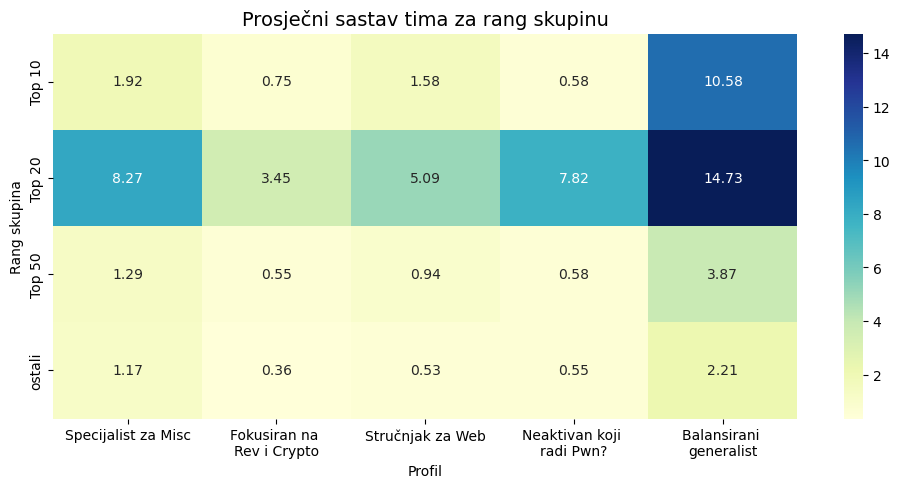

In [155]:
# Calculate the average number of each specialist per team in each bucket
bucket_averages = team_structure_grouped.groupby('rank_bucket')[ordered_names_5].mean()

# Reorder buckets
bucket_order = ['Top 10', 'Top 20', 'Top 50', 'ostali']
bucket_averages = bucket_averages.reindex(bucket_order)

plt.figure(figsize=(12, 5))
sns.heatmap(bucket_averages, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Prosječni sastav tima za rang skupinu", fontsize=14)
plt.xlabel("Profil")
plt.ylabel("Rang skupina")
plt.show()

In [168]:
cluster_info_nonpublic_5 = {
    0: {"name": "Specijalist za Misc", "color": "blue"},
    1: {"name": "Fokusiran na \nRev i Crypto", "color": "orange"},
    2: {"name": "Stručnjak za Web", "color": "green"},
    3: {"name": "Neaktivan koji \nradi Pwn?", "color": "red"},
    4: {"name": "Balansirani \ngeneralist", "color": "purple"},
    5: {"name": "Nonpublic", "color": "black"}
}

# Helper objects for plotting
name_map_nonpublic_5 = {k: v["name"] for k, v in cluster_info_nonpublic_5.items()}
color_map_nonpublic_5 = {v["name"]: v["color"] for k, v in cluster_info_nonpublic_5.items()}
ordered_names_nonpublic_5 = [cluster_info_nonpublic_5[i]["name"] for i in range(6)]

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info_nonpublic_5.values()
]

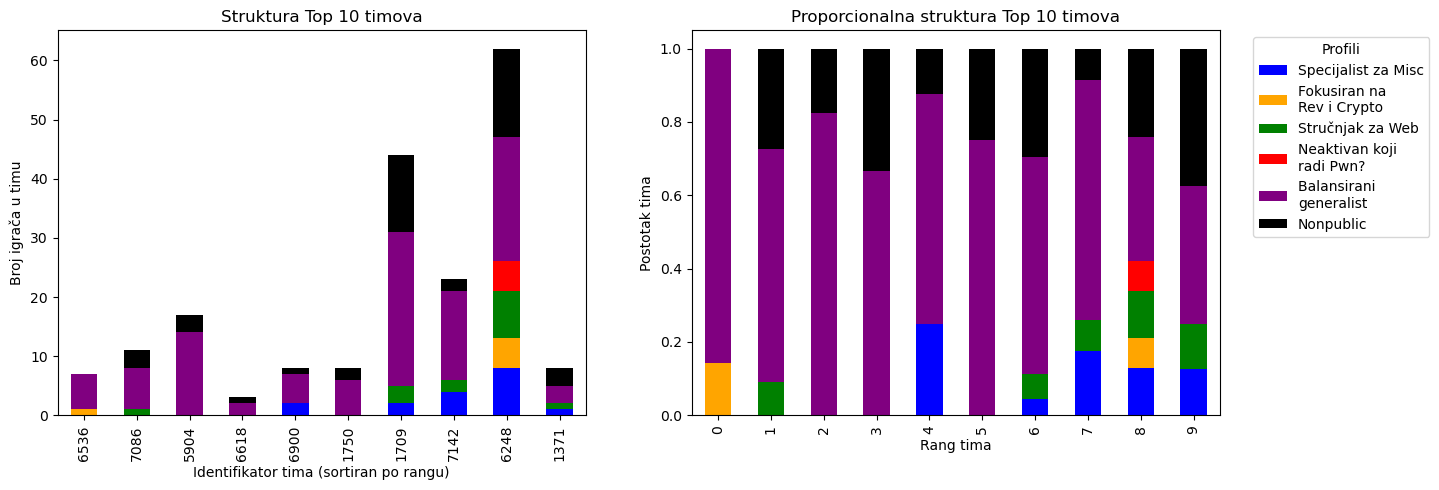

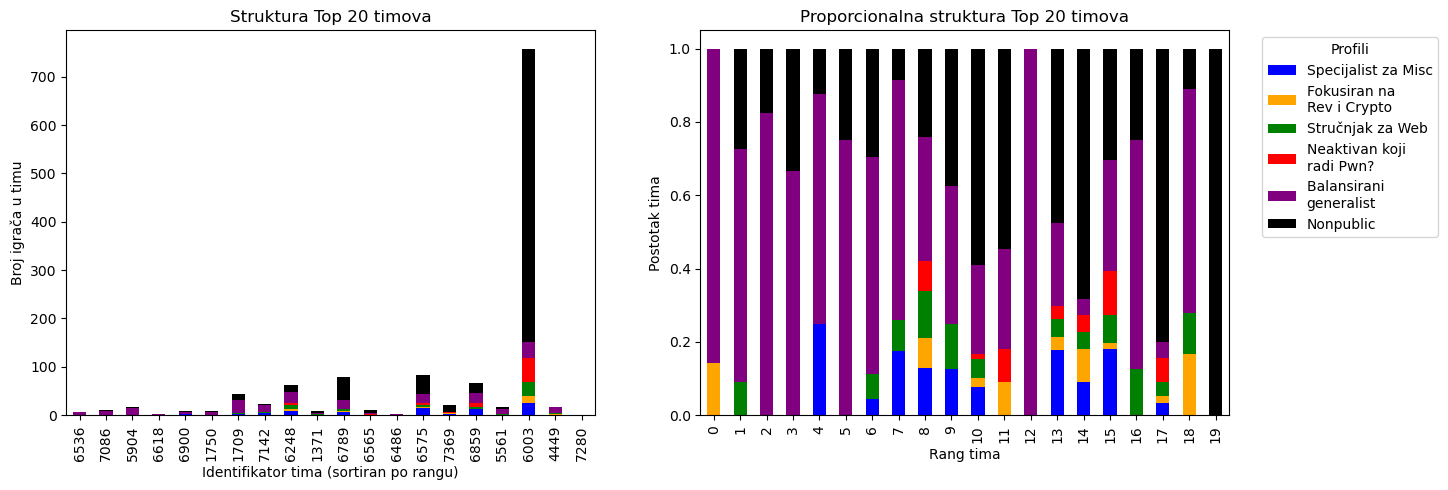

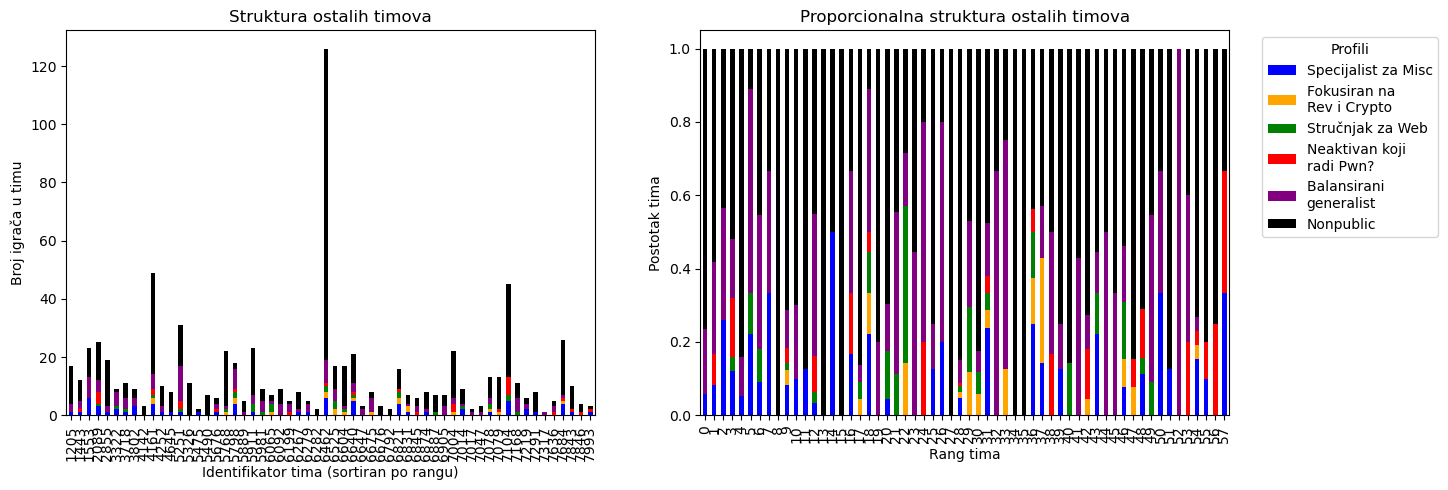

In [169]:
generate_all_bar_plots(team_structure_grouped, ordered_names_nonpublic_5, color_map_nonpublic_5)

#### Clustering na grupiranom datasetu na temelju glavnih kategorija - 11 clustera

In [15]:
cluster_info_11 = {
    0: {"name": "Specijalist za Misc \ndodatno usmjeren \nna Web", "color": "blue"},
    1: {"name": "Generalist \nspecijaliziran \nza forenziku", "color": "orange"},
    2: {"name": "Generalist usmjeren \nna Web", "color": "green"},
    3: {"name": "Stručnjak za Web", "color": "red"},
    4: {"name": "Specijalist za Pwn", "color": "purple"},
    5: {"name": "Balansirani generalist", "color": "brown"},
    6: {"name": "Specijalist za \nreverzno \ninženjerstvo", "color": "pink"},
    7: {"name": "Neaktivan korisnik", "color": "gray"}, 
    8: {"name": "Stručnjak za \nkriptografiju", "color": "tab:olive"},
    9: {"name": "Stručnjak za Misc", "color": "cyan"},
    10: {"name": "Generalist \nusmjeren na Misc", "color": "fuchsia"}
}

# Helper objects for plotting
name_map_11 = {k: v["name"] for k, v in cluster_info_11.items()}
color_map_11 = {v["name"]: v["color"] for k, v in cluster_info_11.items()}
ordered_names_11 = [cluster_info_11[i]["name"] for i in range(11)]
color_list_11 = [v for k, v in color_map_11.items()]
legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info_11.values()
]

##### Grafovi

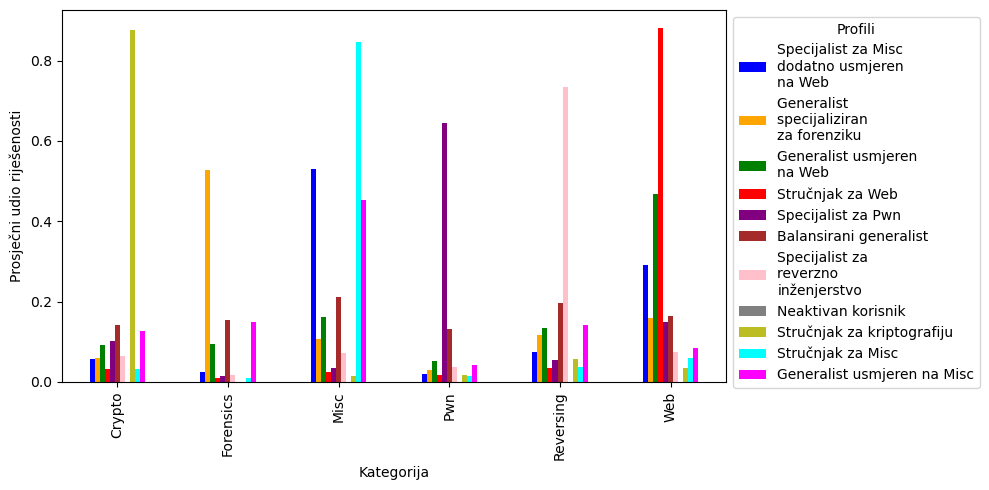

In [11]:
km = KMeans(n_clusters=11, random_state=0, n_init='auto')
clusters = km.fit_predict(profiles)
profile_clustered_main_11 = profiles.copy()
profile_clustered_main_11['cluster'] = clusters

cluster_mean_11 = profile_clustered_main_11.groupby('cluster').mean()
cluster_mean_11.T.plot(kind='bar', figsize=(10, 5), color=color_list_11)
plt.xlabel('Kategorija')
plt.ylabel('Prosječni udio riješenosti')

plt.legend(
    handles=legend_elements, 
    title='Profili', 
    bbox_to_anchor=(1, 1)
)
plt.tight_layout()
plt.show()

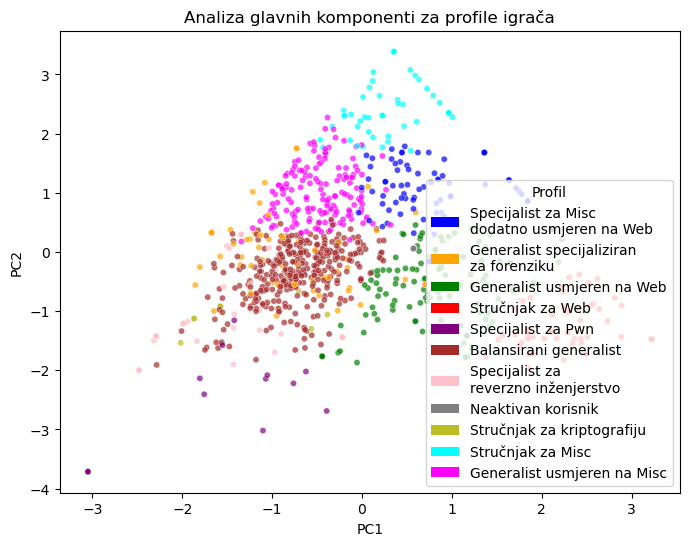

In [135]:
get_pca_graph(profiles, clusters, name_map_11, ordered_names_11, color_map_11, legend_elements)


pc2 izgleda kao da je misc kategorija - koliko se rjesaavao misc u odnosu na ostale kategorije?. noob ima 0 u tome jer nije rjeavao nista
pc1 izgleda kao najcesca vj najslabija rijesenost? Ili specijalizacija po ostalim kateogrijama - u sredini su vise generalisti, lijevo je ekipa koja je rjesavala tradicionalno teze k ategorije, a desno je web

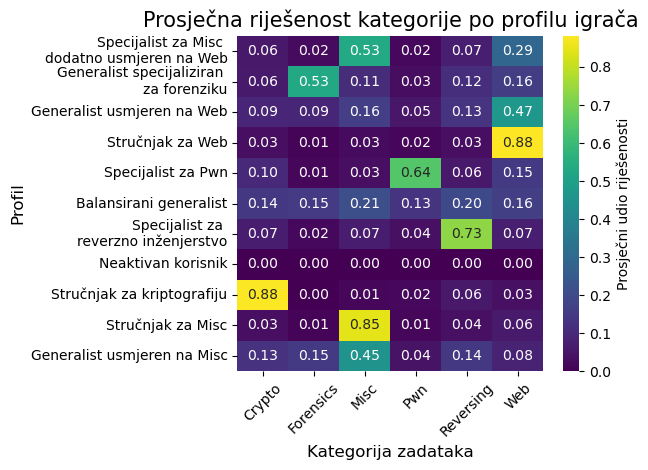

In [172]:
category_order = ["Crypto", "Forensics", "Misc","Pwn", "Reversing", "Web"]

avg_heatmap_data_11 = cluster_mean_11.copy()
avg_heatmap_data_11.index = avg_heatmap_data_11.index.map(lambda x: cluster_info_11[x]['name'])
avg_heatmap_data_11 = avg_heatmap_data_11.reindex(columns=category_order)
get_avg_profile_heatmap(avg_heatmap_data_11)

In [173]:
# Assuming X is your scaled feature matrix and labels_11 is your k=11 results
dbi_11 = davies_bouldin_score(profiles, clusters)
print(f"Davies-Bouldin Index (k=11): {dbi_11:.4f}")

Davies-Bouldin Index (k=11): 0.9595


Davies-bouldin index je manji za k=11 nego za k=5, znači da grupiranje ima smisla, grupe su dovoljno guste da se još uvijek mogu smatrati zasebno vrijednim grupama

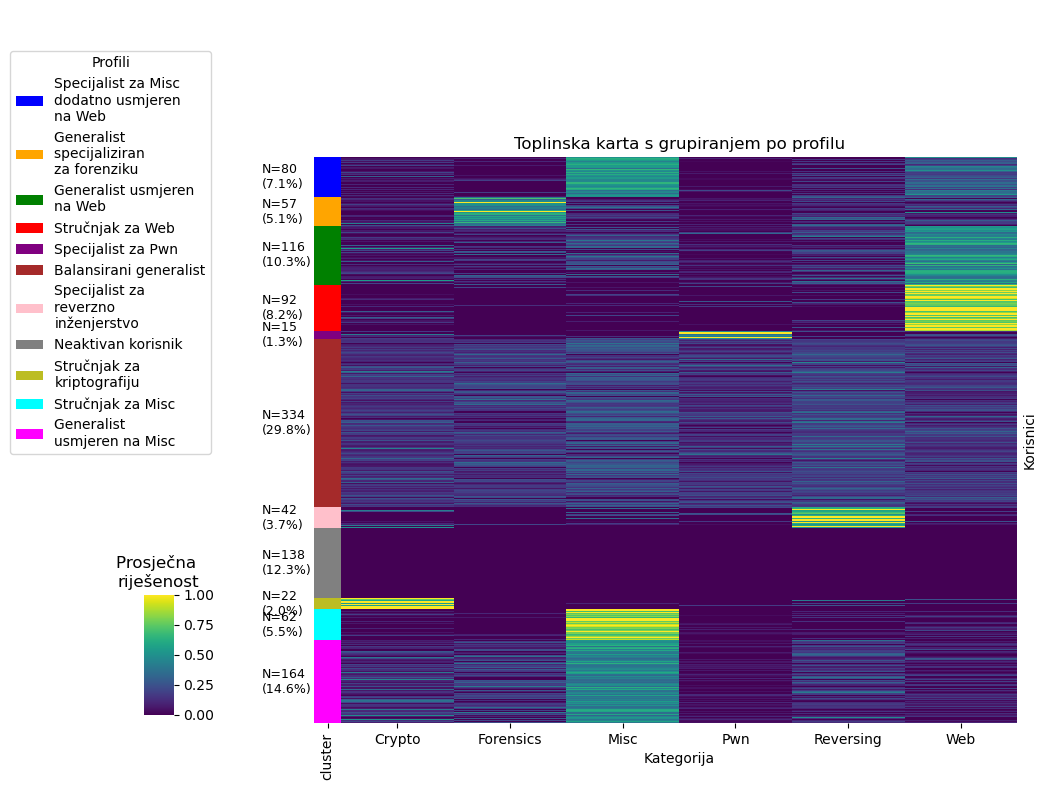

In [18]:
profile_sorted = profile_clustered_main_11.sort_values('cluster')
row_colors = profile_sorted['cluster'].map(lambda x: cluster_info_11[x]['color'])

get_clustermap(profile_sorted, row_colors, cluster_info_11)

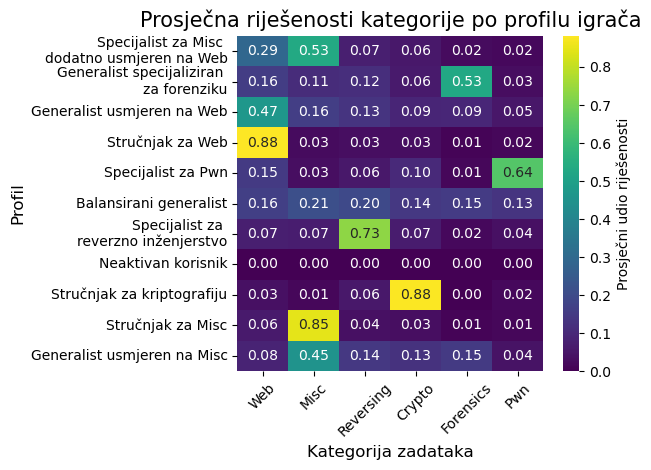

In [137]:
# Average archetype profiles
category_order = ["Web", "Misc", "Reversing", "Crypto", "Forensics", "Pwn"]

avg_heatmap_data_11 = cluster_mean_11.copy()
avg_heatmap_data_11.index = avg_heatmap_data_11.index.map(lambda x: cluster_info_11[x]['name'])
avg_heatmap_data_11 = avg_heatmap_data_11.reindex(columns=category_order)
get_avg_profile_heatmap(avg_heatmap_data_11)

In [148]:
import joblib

In [149]:
# You MUST save the scaler AND the model
joblib.dump(km, 'htb_model.joblib')

['htb_model.joblib']

spremam ovaj klasifikator za raditi predikcije na ringzer0 datasetu

##### Team structure

In [18]:
profile_clustered_main_11 = profile_clustered_main_11.reset_index()
profile_clustered_main_11 = profile_clustered_main_11.rename(columns={'index': 'id'})
profile_clustered_main_11['id'] = pd.to_numeric(profile_clustered_main_11['id'])


ranks = teams_df[['id', 'rank']].rename(columns={'rank': 'team_rank', 'id': 'team_id'})
team_structure_df_11 = team_members_df[['id', 'team_id', 'rank']].merge(
    profile_clustered_main_11[['id', 'cluster']], 
    on='id',
    how='left'
).rename(columns={'rank': 'user_rank'}).merge(
    ranks,
    on='team_id',
    how='left'
)

team_structure_df_11.describe()

,id,team_id,cluster,team_rank
count,2.865000e+03,2865.000000,1122.000000,2865.000000
mean,1.217990e+06,5347.560209,5.246881,33.914834
std,7.961807e+05,1827.860351,3.009739,28.186946
min,3.810000e+02,91.000000,0.000000,1.000000
25%,4.488120e+05,4252.000000,3.000000,15.000000
50%,1.252835e+06,6003.000000,5.000000,18.000000
75%,1.950753e+06,6555.000000,7.000000,56.000000
max,2.913874e+06,7993.000000,10.000000,100.000000


In [19]:
team_structure_df_11['cluster_name'] = team_structure_df_11['cluster'].map(name_map_11).fillna("Nonpublic")
team_structure_grouped_11 = team_structure_df_11.groupby(['team_id', 'team_rank'])['cluster_name'].value_counts().unstack(fill_value=0)
team_structure_grouped_11['team_size'] = team_structure_grouped_11.sum(axis=1)
team_structure_grouped_11['rank_bucket'] = team_structure_grouped_11.index.get_level_values('team_rank').map(get_bucket)

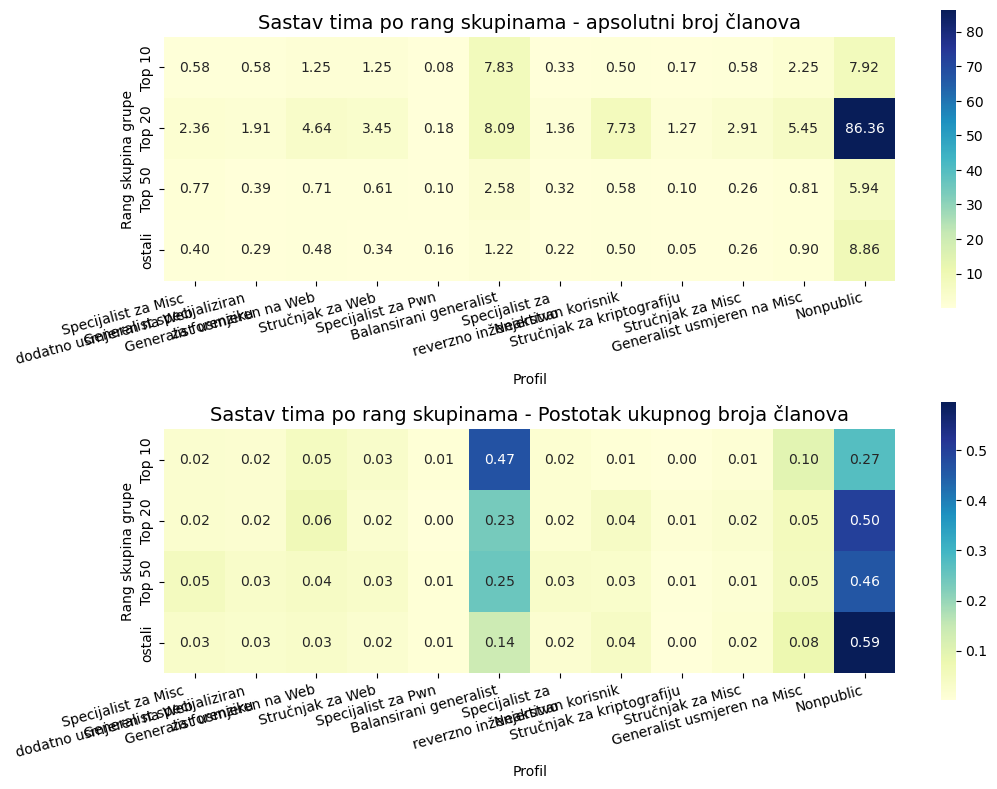

In [20]:
# Calculate the average number of each specialist per team in each bucket
all_profiles = ordered_names_11 + ['Nonpublic']
bucket_averages_absolute = team_structure_grouped_11.groupby('rank_bucket')[all_profiles].mean()

# Reorder buckets
bucket_order = ['Top 10', 'Top 20', 'Top 50', 'ostali']
bucket_averages_absolute = bucket_averages_absolute.reindex(bucket_order)
fig, ax = plt.subplots(2, 1, figsize=(11, 8))
sns.heatmap(bucket_averages_absolute, annot=True, cmap="YlGnBu", fmt=".2f", ax=ax[0], square=True)
ax[0].set_title("Sastav tima po rang skupinama - apsolutni broj članova", fontsize=14)
ax[0].set_xlabel("Profil")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=15, ha='right')
ax[0].set_ylabel("Rang skupina grupe")

team_structure_percentage_11 = team_structure_grouped_11.copy()
team_structure_percentage_11[all_profiles] = team_structure_grouped_11[all_profiles].div(team_structure_grouped_11['team_size'], axis=0)
bucket_averages_percentage = team_structure_percentage_11.groupby('rank_bucket')[all_profiles].mean()
bucket_averages_percentage = bucket_averages_percentage.reindex(bucket_order)

sns.heatmap(bucket_averages_percentage, annot=True, cmap="YlGnBu", fmt=".2f", ax=ax[1], square=True)
ax[1].set_title("Sastav tima po rang skupinama - Postotak ukupnog broja članova", fontsize=14)
ax[1].set_xlabel("Profil")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=15, ha='right')
ax[1].set_ylabel("Rang skupina grupe")
plt.tight_layout()


In [149]:
group1 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 10']['Balansirani generalist']
group2 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 20']['Balansirani generalist']
group3 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 50']['Balansirani generalist']
group4 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'ostali']['Balansirani generalist']

h_stat, p_val = kruskal(group1, group2, group3, group4)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

H-statistic: 21.0006
p-value: 0.0001


In [152]:
dunn_df = sp.posthoc_dunn(
    team_structure_percentage_11, 
    val_col='Balansirani generalist', 
    group_col='rank_bucket', 
    p_adjust='bonferroni' # Standard correction for multiple comparisons
)
print("Dunn's Test P-Value Matrix:")
print(dunn_df)

Dunn's Test P-Value Matrix:
          Top 10    Top 20    Top 50    ostali
Top 10  1.000000  0.095673  0.065102  0.000070
Top 20  0.095673  1.000000  1.000000  1.000000
Top 50  0.065102  1.000000  1.000000  0.111078
ostali  0.000070  1.000000  0.111078  1.000000


In [157]:
group1 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 10']['Neaktivan korisnik']
group2 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 20']['Neaktivan korisnik']
group3 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 50']['Neaktivan korisnik']
group4 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'ostali']['Neaktivan korisnik']

h_stat, p_val = kruskal(group1, group2, group3, group4)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

H-statistic: 4.6964
p-value: 0.1954


In [158]:
group1 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 10']['Nonpublic']
group2 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 20']['Nonpublic']
group3 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'Top 50']['Nonpublic']
group4 = team_structure_percentage_11[team_structure_percentage_11['rank_bucket'] == 'ostali']['Nonpublic']

h_stat, p_val = kruskal(group1, group2, group3, group4)

print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

dunn_df = sp.posthoc_dunn(
    team_structure_percentage_11, 
    val_col='Nonpublic', 
    group_col='rank_bucket', 
    p_adjust='bonferroni' # Standard correction for multiple comparisons
)

print("Dunn's Test P-Value Matrix:")
print(dunn_df)

H-statistic: 16.4365
p-value: 0.0009
Dunn's Test P-Value Matrix:
          Top 10    Top 20    Top 50    ostali
Top 10  1.000000  0.246823  0.240149  0.000859
Top 20  0.246823  1.000000  1.000000  1.000000
Top 50  0.240149  1.000000  1.000000  0.134817
ostali  0.000859  1.000000  0.134817  1.000000


Dokazano da postoji statistički značajna razlika u broju generalista u skupini top 10 timova i timova rangiranih ispod 50. mjesta. Dokazano je i da je u prvih 10 timova manje nejavnih profila nego u ostalima, ali razlika u broju početnika nije statistički značajna. 

In [167]:
cluster_info_nonpublic_11 = {
    0: {"name": "Specijalist za Misc \ndodatno usmjeren na Web", "color": "blue"},
    1: {"name": "Generalist specijaliziran \nza forenziku", "color": "orange"},
    2: {"name": "Generalist usmjeren na Web", "color": "green"},
    3: {"name": "Stručnjak za Web", "color": "red"},
    4: {"name": "Specijalist za Pwn", "color": "purple"},
    5: {"name": "Balansirani generalist", "color": "brown"},
    6: {"name": "Specijalist za \nreverzno inženjerstvo", "color": "pink"},
    7: {"name": "Neaktivan korisnik", "color": "gray"}, 
    8: {"name": "Stručnjak za kriptografiju", "color": "tab:olive"},
    9: {"name": "Stručnjak za Misc", "color": "cyan"},
    10: {"name": "Generalist usmjeren na Misc", "color": "fuchsia"},
    11: {"name": "Nonpublic", "color": "black"}
}

# Helper objects for plotting
name_map_nonpublic_11 = {k: v["name"] for k, v in cluster_info_nonpublic_11.items()}
color_map_nonpublic_11 = {v["name"]: v["color"] for k, v in cluster_info_nonpublic_11.items()}
ordered_names_nonpublic_11 = [cluster_info_nonpublic_11[i]["name"] for i in range(12)]

legend_elements = [
    Patch(facecolor=info['color'], label=info['name']) 
    for info in cluster_info_nonpublic_11.values()
]

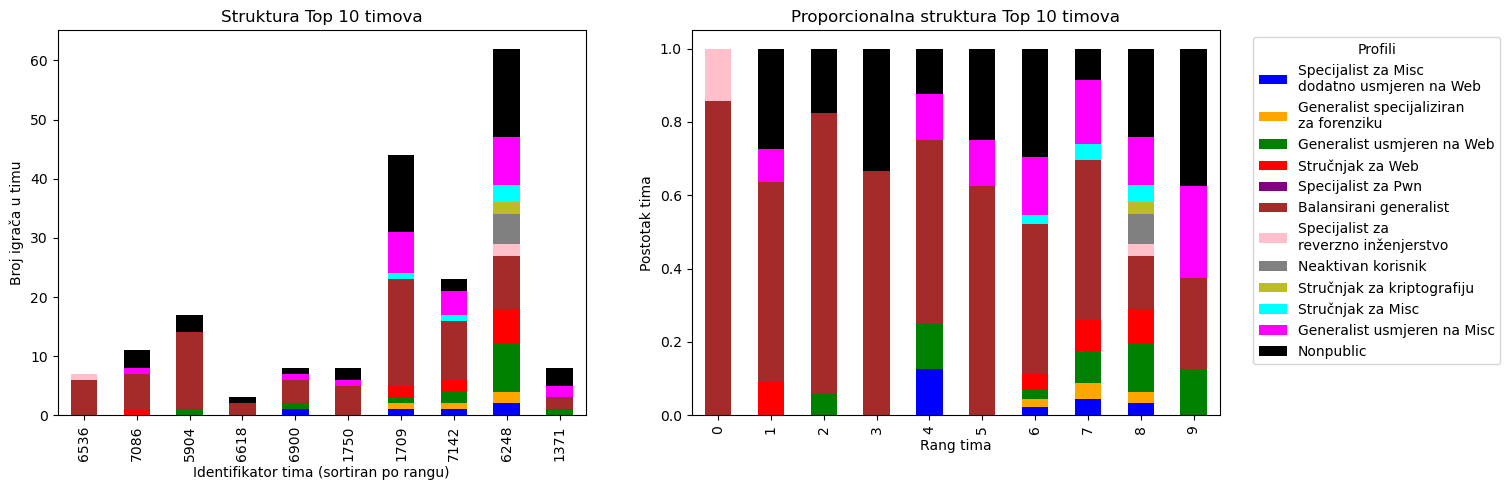

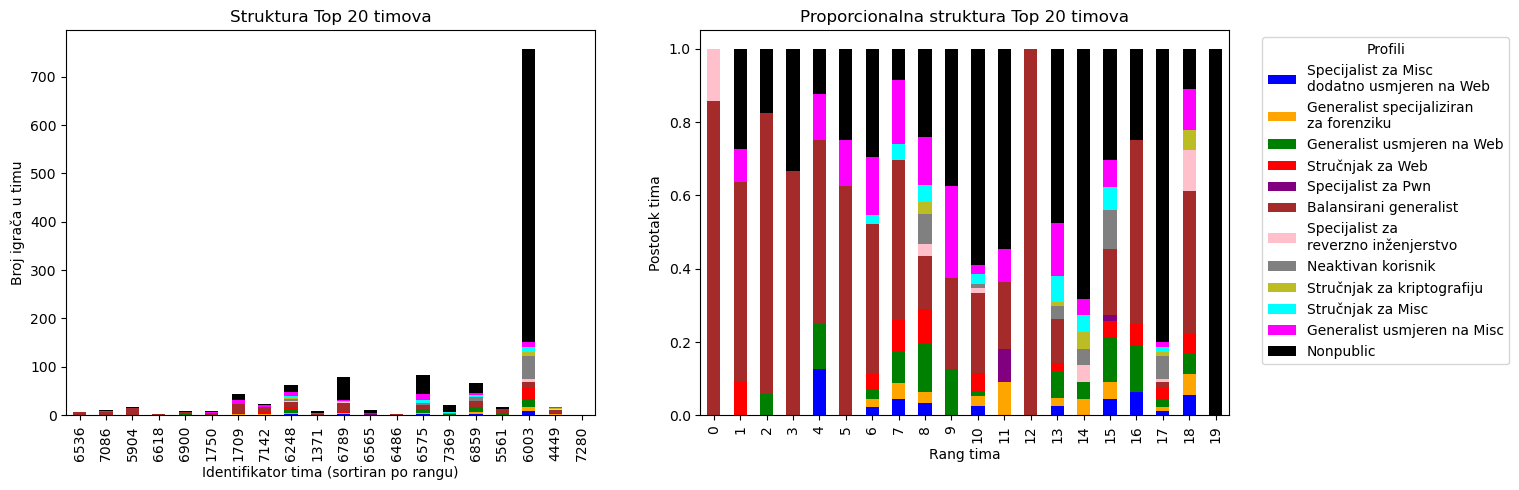

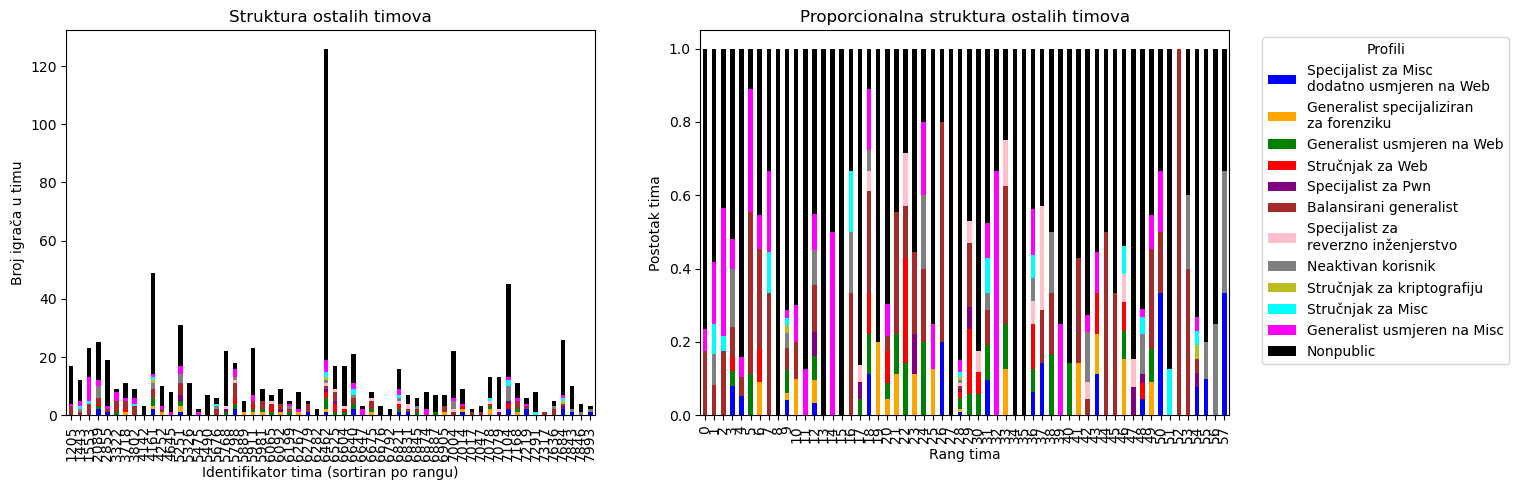

In [ ]:
generate_all_bar_plots(team_structure_grouped_11, ordered_names_nonpublic_11, color_map_nonpublic_11)

### Struktura tima - timovi s jako niskim rezidualima

In [21]:
team_structure_grouped_11

,cluster_name,Balansirani generalist,Generalist specijaliziran \nza forenziku,Generalist usmjeren na Misc,Generalist usmjeren na Web,Neaktivan korisnik,Nonpublic,Specijalist za \nreverzno inženjerstvo,Specijalist za Misc \ndodatno usmjeren na Web,Specijalist za Pwn,Stručnjak za Misc,Stručnjak za Web,Stručnjak za kriptografiju,team_size,rank_bucket
team_id,team_rank,,,,,,,,,,,,,,
91,27,1,0,1,0,1,6,0,1,0,2,0,0,12,Top 50
394,32,1,0,0,0,0,0,0,0,0,0,0,0,1,Top 50
556,30,1,0,0,0,0,1,0,0,0,0,0,0,2,Top 50
1205,92,3,0,1,0,0,13,0,0,0,0,0,0,17,ostali
1371,9,2,0,2,1,0,3,0,0,0,0,0,0,8,Top 10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7666,41,1,1,1,1,0,2,0,0,0,0,0,0,6,Top 50
7684,87,1,0,1,0,0,19,0,2,1,1,0,1,26,ostali
7843,79,0,0,0,0,1,8,0,1,0,0,0,0,10,ostali


(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5]),
 [Text(0.5, 0, 'Balansirani generalist'),
  Text(1.5, 0, 'Generalist specijaliziran \nza forenziku'),
  Text(2.5, 0, 'Generalist usmjeren na Misc'),
  Text(3.5, 0, 'Generalist usmjeren na Web'),
  Text(4.5, 0, 'Neaktivan korisnik'),
  Text(5.5, 0, 'Nonpublic'),
  Text(6.5, 0, 'Specijalist za \nreverzno inženjerstvo'),
  Text(7.5, 0, 'Specijalist za Misc \ndodatno usmjeren na Web'),
  Text(8.5, 0, 'Specijalist za Pwn'),
  Text(9.5, 0, 'Stručnjak za Misc'),
  Text(10.5, 0, 'Stručnjak za Web'),
  Text(11.5, 0, 'Stručnjak za kriptografiju')])

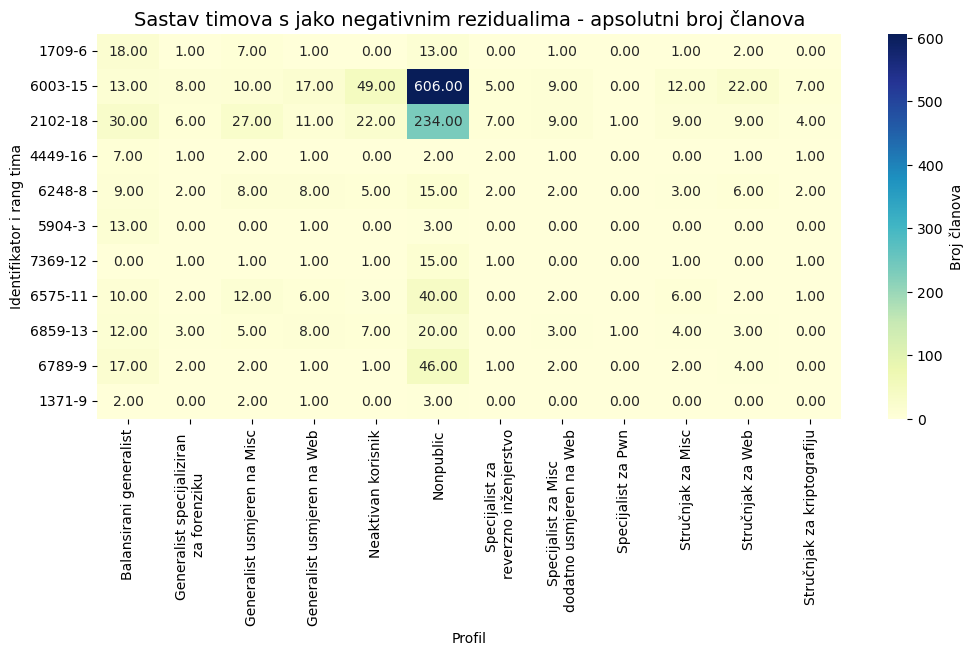

In [48]:
ids = [1709, 6003, 2102, 4449, 6248, 5904, 7369, 6575, 6859, 6789, 1371]
chosen_teams = team_structure_grouped_11.loc[ids].drop(columns=["rank_bucket", "team_size"])
all_profiles = ordered_names_11 + ['Nonpublic']
plt.figure(figsize=(12,5))
sns.heatmap(chosen_teams, annot=True, cmap="YlGnBu", fmt=".2f", cbar_kws=({"label":"Broj članova"}))
plt.title("Sastav timova s jako negativnim rezidualima - apsolutni broj članova", fontsize=14)
plt.xlabel("Profil")
plt.ylabel("Identifikator i rang tima")
plt.xticks(rotation=90)

Text(120.72222222222221, 0.5, 'Identifikator i rang tima')

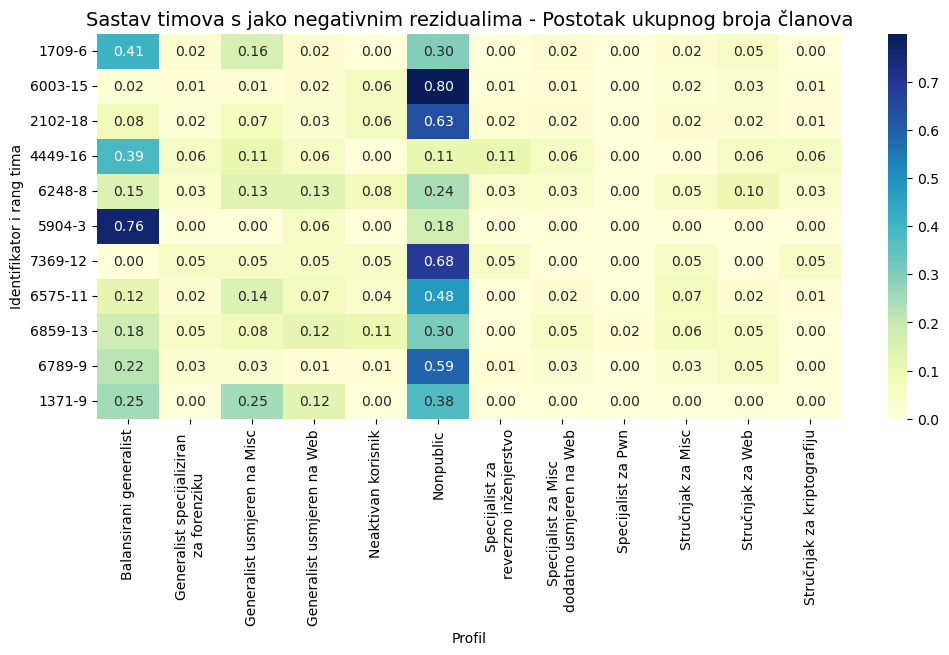

In [55]:
team_structure_percentage_11 = team_structure_grouped_11.copy()
team_structure_percentage_11[all_profiles] = team_structure_grouped_11[all_profiles].div(team_structure_grouped_11['team_size'], axis=0)
chosen_teams_percentage = team_structure_percentage_11.loc[ids].drop(columns=(["rank_bucket", "team_size"]))
plt.figure(figsize=(12,5))
sns.heatmap(chosen_teams_percentage, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Sastav timova s jako negativnim rezidualima - Postotak ukupnog broja članova", fontsize=14)
plt.xlabel("Profil")
plt.ylabel("Identifikator i rang tima")


### Dendrogram - smanjenje broja profila

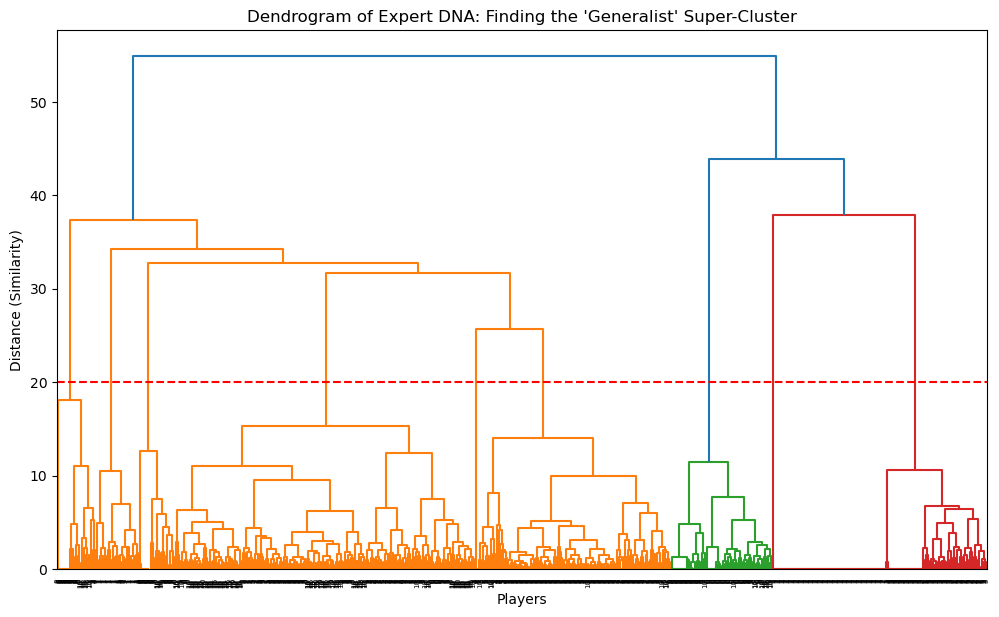

In [96]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# 1. Prepare your features (e.g., normalized category point counts)
X = profile_clustered_main_11.copy()
X = X.drop(columns=['cluster', 'id'])

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Perform Linkage (Ward's method is best for minimizing variance)
Z = sch.linkage(X_scaled, method='ward') 

# 3. Plot the Dendrogram
plt.figure(figsize=(12, 7))
dendrogram = sch.dendrogram(Z, leaf_rotation=90, labels=profile_clustered_main_11['cluster'].values)
plt.title("Dendrogram of Expert DNA: Finding the 'Generalist' Super-Cluster")
plt.xlabel("Players")
plt.ylabel("Distance (Similarity)")
plt.axhline(y=20, color='r', linestyle='--') # Example threshold to 'cut' the tree
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=9, linkage='ward')
cluster_labels = model.fit_predict(X_scaled)

# Add these back to your dataframe
profile_clustered_main_11['super_cluster'] = cluster_labels

comparison = pd.crosstab(profile_clustered_main_11['cluster'], profile_clustered_main_11['super_cluster'])
print(comparison)

super_cluster   0    1   2    3    4   5   6  7   8
cluster                                            
0               0   29   0    2    0   0   0  0  49
1               2   10   0    0    0   0  45  0   0
2               2   71   0   13    0  30   0  0   0
3               0    0   0    0    0  92   0  0   0
4               0    0   0   10    0   0   0  5   0
5               6  120   3  199    0   0   6  0   0
6               6    0  36    0    0   0   0  0   0
7               0    0   0    0  138   0   0  0   0
8              22    0   0    0    0   0   0  0   0
9               0    0   0    0    0   0   0  0  62
10              9  131   6    7    0   0   0  0  11
